# Forget

In [1]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com' # Set Hugging Face endpoint to a mirror
os.chdir('./Interkcat')

In [2]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
from typing import List, NamedTuple, Optional

import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool, global_max_pool, MessagePassing

from rdkit import Chem

from transformers import AutoTokenizer, AutoModel

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
# Dataset class for kcat prediction
class KcatDataset(Dataset):
    def __init__(self, sequences, smiles_list, kcats):
        assert len(sequences) == len(smiles_list) == len(kcats)
        self.sequences = sequences
        self.smiles_list = smiles_list
        self.kcats = kcats

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.smiles_list[idx], self.kcats[idx]
    
def collate_fn(batch):
    sequences, smiles_list, kcats = zip(*batch)
    kcats = torch.tensor(kcats, dtype=torch.float32)
    return list(sequences), list(smiles_list), kcats


# Protein Embedding Layer using pre-trained transformer model
class ProteinEmbeddingLayer(nn.Module):
    def __init__(
        self,
        model_name: str = "facebook/esm2_t30_150M_UR50D",
        freeze: bool = True,
        unfreeze_last_n: int = 0,
        device: str = None
    ):
        super().__init__()
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        
        for param in self.model.parameters():
            param.requires_grad = False

        if not freeze:
            if unfreeze_last_n == 0:
                # Fully unfreeze the model
                for param in self.model.parameters():
                    param.requires_grad = True
                self.model.train()
            else:
                # unfreeze_last_n > 0
                num_layers = len(self.model.encoder.layer)
                unfreeze_start_idx = num_layers - unfreeze_last_n
                
                # unfreeze transformer layers
                for i in range(unfreeze_start_idx, num_layers):
                    for param in self.model.encoder.layer[i].parameters():
                        param.requires_grad = True
                
                if hasattr(self.model, 'contact_head'):
                    for param in self.model.contact_head.parameters():
                        param.requires_grad = True
                
                self.model.train()
        else:
            self.model.eval()

    def forward(self, sequences, return_symbols: bool = False):
        if isinstance(sequences, str):
            sequences = [sequences]

        encoded = self.tokenizer(
            sequences,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=1024,
            add_special_tokens=True
        )
        
        input_ids = encoded['input_ids'].to(self.device)
        attention_mask = encoded['attention_mask'].to(self.device)
        
        is_train = any(p.requires_grad for p in self.model.parameters())
        with torch.set_grad_enabled(is_train):
            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                return_dict=True
            )
            last_hidden = outputs.last_hidden_state  # (B, L_with_special, D)

        embeddings_list = []
        mask_list = []
        symbols_list = [] if return_symbols else None

        for i in range(last_hidden.size(0)):
            seq_len_with_special = attention_mask[i].sum().item()
            real_residues = last_hidden[i, 1:seq_len_with_special - 1, :]  # (L_real, D)
            embeddings_list.append(real_residues)
            real_mask = torch.ones(real_residues.size(0), dtype=torch.bool, device=self.device)
            mask_list.append(real_mask)

            if return_symbols:
                input_ids_i = input_ids[i]  # (L_with_special,)
                real_input_ids = input_ids_i[1:seq_len_with_special - 1].cpu().tolist()
                real_symbols = self.tokenizer.convert_ids_to_tokens(real_input_ids)
                symbols_list.append(real_symbols)

        # Padding embeddings
        embeddings_padded = torch.nn.utils.rnn.pad_sequence(
            embeddings_list, batch_first=True, padding_value=0.0
        )  # (B, L_max, D)

        # Padding masks
        mask_padded = torch.nn.utils.rnn.pad_sequence(
            mask_list, batch_first=True, padding_value=False
        )  # (B, L_max)

        if return_symbols:
            return embeddings_padded, mask_padded, symbols_list
        else:
            return embeddings_padded, mask_padded
        
# Molecular Embedding Layer
# Functions to convert SMILES to graph representation
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')  # Suppress RDKit warnings

# Functions to convert SMILES to graph representation
allowable_features = {
    'possible_atomic_num_list': list(range(1, 119)) + ['misc'],
    'possible_chirality_list': [
        'CHI_UNSPECIFIED', 'CHI_TETRAHEDRAL_CW', 'CHI_TETRAHEDRAL_CCW', 'CHI_OTHER', 'misc'
    ],
    'possible_degree_list': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'misc'],
    'possible_formal_charge_list': [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 'misc'],
    'possible_numH_list': [0, 1, 2, 3, 4, 5, 6, 7, 8, 'misc'],
    'possible_number_radical_e_list': [0, 1, 2, 3, 4, 'misc'],
    'possible_hybridization_list': ['SP', 'SP2', 'SP3', 'SP3D', 'SP3D2', 'misc'],
    'possible_is_aromatic_list': [False, True],
    'possible_is_in_ring_list': [False, True],
    'possible_bond_type_list': ['SINGLE', 'DOUBLE', 'TRIPLE', 'AROMATIC', 'misc'],
    'possible_bond_stereo_list': [
        'STEREONONE', 'STEREOZ', 'STEREOE', 'STEREOCIS', 'STEREOTRANS', 'STEREOANY'
    ],
    'possible_is_conjugated_list': [False, True],
}

def safe_index(l, e):
    try:
        return l.index(e)
    except ValueError:
        return len(l) - 1

def atom_to_feature_vector(atom):
    return [
        safe_index(allowable_features['possible_atomic_num_list'], atom.GetAtomicNum()),
        safe_index(allowable_features['possible_chirality_list'], str(atom.GetChiralTag())),
        safe_index(allowable_features['possible_degree_list'], atom.GetTotalDegree()),
        safe_index(allowable_features['possible_formal_charge_list'], atom.GetFormalCharge()),
        safe_index(allowable_features['possible_numH_list'], atom.GetTotalNumHs()),
        safe_index(allowable_features['possible_number_radical_e_list'], atom.GetNumRadicalElectrons()),
        safe_index(allowable_features['possible_hybridization_list'], str(atom.GetHybridization())),
        allowable_features['possible_is_aromatic_list'].index(atom.GetIsAromatic()),
        allowable_features['possible_is_in_ring_list'].index(atom.IsInRing()),
    ]

def bond_to_feature_vector(bond):
    return [
        safe_index(allowable_features['possible_bond_type_list'], str(bond.GetBondType())),
        allowable_features['possible_bond_stereo_list'].index(str(bond.GetStereo())),
        allowable_features['possible_is_conjugated_list'].index(bond.GetIsConjugated()),
    ]

def smiles2graph(smiles_string, removeHs=True, max_nodes=None):
    mol = Chem.MolFromSmiles(smiles_string)
    if mol is None:
        return None
    mol = mol if removeHs else Chem.AddHs(mol)
    if max_nodes is not None and mol.GetNumAtoms() > max_nodes:
        return None

    atom_features_list = []
    for atom in mol.GetAtoms():
        atom_features_list.append(atom_to_feature_vector(atom))
    node_feat = np.array(atom_features_list, dtype=np.int64)

    num_bond_features = 3
    if len(mol.GetBonds()) > 0:
        edges_list, edge_features_list = [], []
        for bond in mol.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            edge_feature = bond_to_feature_vector(bond)
            edges_list.extend([(i, j), (j, i)])
            edge_features_list.extend([edge_feature, edge_feature])
        edge_index = np.array(edges_list, dtype=np.int64).T
        edge_feat = np.array(edge_features_list, dtype=np.int64)
    else:
        edge_index = np.empty((2, 0), dtype=np.int64)
        edge_feat = np.empty((0, num_bond_features), dtype=np.int64)

    return {
        'node_feat': node_feat,
        'edge_index': edge_index,
        'edge_feat': edge_feat,
        'num_nodes': len(node_feat)
    }

# model components
class AtomEncoder(nn.Module):
    def __init__(self, emb_dim: int):
        super().__init__()
        keys = [
            'possible_atomic_num_list', 'possible_chirality_list', 'possible_degree_list',
            'possible_formal_charge_list', 'possible_numH_list', 'possible_number_radical_e_list',
            'possible_hybridization_list', 'possible_is_aromatic_list', 'possible_is_in_ring_list'
        ]
        self.embeddings = nn.ModuleList([
            nn.Embedding(len(allowable_features[k]), emb_dim) for k in keys
        ])
        for emb in self.embeddings:
            nn.init.xavier_uniform_(emb.weight)

    def forward(self, x):
        return sum(emb(x[:, i]) for i, emb in enumerate(self.embeddings))


class BondEncoder(nn.Module):
    def __init__(self, emb_dim: int):
        super().__init__()
        keys = ['possible_bond_type_list', 'possible_bond_stereo_list', 'possible_is_conjugated_list']
        self.embeddings = nn.ModuleList([
            nn.Embedding(len(allowable_features[k]), emb_dim) for k in keys
        ])
        for emb in self.embeddings:
            nn.init.xavier_uniform_(emb.weight)

    def forward(self, edge_attr):
        return sum(emb(edge_attr[:, i]) for i, emb in enumerate(self.embeddings))


class GNNCov(MessagePassing):
    def __init__(self, emb_dim: int, use_gat: bool = False, heads: int = 4):
        super(GNNCov, self).__init__(aggr="add")
        self.use_gat = use_gat
        
        if use_gat:
            self.conv = GATConv(emb_dim, emb_dim // heads, heads=heads, edge_dim=emb_dim)
        else:
            self.conv = GCNConv(emb_dim, emb_dim)
            
        self.batch_norm = nn.BatchNorm1d(emb_dim)
        self.res_fc = nn.Linear(emb_dim, emb_dim)

    def forward(self, x, edge_index, edge_attr):
        if self.use_gat:
            h = self.conv(x, edge_index, edge_attr=edge_attr)
        else:
            h = self.conv(x, edge_index) + self.message_fusion(x, edge_index, edge_attr)
            
        # residual connection
        x = F.relu(self.batch_norm(x + h))
        return x

    def message_fusion(self, x, edge_index, edge_attr):
        row, col = edge_index
        return self.propagate(edge_index, x=x, edge_attr=edge_attr)

    def message(self, edge_attr):
        return F.relu(edge_attr)


class MoleculeEmbeddingOutput(NamedTuple):
    atom_embeddings: torch.Tensor      # (B, L, D)
    atom_mask: torch.Tensor           # (B, L)
    atom_symbols: Optional[List[List[str]]]

class MolecularEmbeddingLayer(nn.Module):
    def __init__(
        self,
        hidden_dim: int = 300,
        num_layers: int = 3,
        gnn_type: str = "gat", # "gcn" or "gat"
        max_nodes: int = 100
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.max_nodes = max_nodes
        self.atom_encoder = AtomEncoder(hidden_dim)
        self.bond_encoder = BondEncoder(hidden_dim)
        
        # GNN multiple layers
        self.layers = nn.ModuleList([
            GNNCov(hidden_dim, use_gat=(gnn_type == "gat")) 
            for _ in range(num_layers)
        ])
        
        self.post_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(0.1)
        )
        
    def _smiles_to_graph(self, smiles: str):
        try:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None or mol.GetNumAtoms() == 0 or mol.GetNumAtoms() > self.max_nodes:
                raise ValueError
            mol = Chem.RemoveHs(mol)
            symbols = [a.GetSymbol() for a in mol.GetAtoms()]
            graph = smiles2graph(smiles, removeHs=True, max_nodes=self.max_nodes)
            if graph is None:
                raise ValueError
            x = torch.from_numpy(graph['node_feat']).long()
            edge_index = torch.from_numpy(graph['edge_index']).long()
            edge_attr = torch.from_numpy(graph['edge_feat']).long()
            return Data(x=x, edge_index=edge_index, edge_attr=edge_attr), symbols
        except Exception:
            x = torch.zeros((1, 9), dtype=torch.long)
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr = torch.empty((0, 3), dtype=torch.long)
            return Data(x=x, edge_index=edge_index, edge_attr=edge_attr), ['X']

    def forward(
        self,
        smiles_list: List[str],
        return_symbols: bool = True
    ) -> MoleculeEmbeddingOutput:
        # 1. SMILES to Graph
        datas, symbols_list = [], []
        for smi in smiles_list:
            data, symbols = self._smiles_to_graph(smi)
            datas.append(data)
            symbols_list.append(symbols)

        device = next(self.parameters()).device
        batch = Batch.from_data_list(datas).to(device)
        x, edge_index, edge_attr, batch_vec = batch.x, batch.edge_index, batch.edge_attr, batch.batch

        # 2. initial feature embedding
        node_emb = self.atom_encoder(x)
        edge_emb = self.bond_encoder(edge_attr)

        # 3. GNN extract features
        for layer in self.layers:
            node_emb = layer(node_emb, edge_index, edge_emb)
        
        node_emb = self.post_mlp(node_emb)

        # 4. reshape to (B, L, D)
        B = len(smiles_list)
        L = self.max_nodes
        atom_embeddings = torch.zeros(B, L, self.hidden_dim, device=device)
        atom_mask = torch.zeros(B, L, dtype=torch.bool, device=device)

        for i in range(B):
            mask_i = (batch_vec == i)
            atoms_i = node_emb[mask_i]
            n_real = min(atoms_i.size(0), L)
            atom_embeddings[i, :n_real] = atoms_i[:n_real]
            atom_mask[i, :n_real] = True

        return MoleculeEmbeddingOutput(
            atom_embeddings=atom_embeddings,
            atom_mask=atom_mask,
            atom_symbols=symbols_list if return_symbols else None, 
        )
    
# InterKcat Model
class InterKcat(nn.Module):
    def __init__(self, prot_dim: int, mol_dim: int, d: int = 256, dropout: float = 0.1):
        super().__init__()
        self.d = d
        self.prot_dim = prot_dim
        self.mol_dim = mol_dim
        self.dropout = dropout

        self.prot_emb = ProteinEmbeddingLayer(freeze=False, unfreeze_last_n=2)
        self.mol_emb = MolecularEmbeddingLayer(hidden_dim=mol_dim, max_nodes=100)

        # Cross-attention projections
        self.prot_proj_q = nn.Linear(self.prot_dim, self.d)
        self.mol_proj_k = nn.Linear(self.mol_dim, self.d)
        self.mol_proj_v = nn.Linear(self.mol_dim, self.d)

        self.mol_proj_q = nn.Linear(self.mol_dim, self.d)
        self.prot_proj_k = nn.Linear(self.prot_dim, self.d)
        self.prot_proj_v = nn.Linear(self.prot_dim, self.d)

        # Prediction head
        self.proj_h = nn.Linear(2 * d, 2 * d)
        self.norm1 = nn.LayerNorm(2 * d)
        self.dropout1 = nn.Dropout(dropout)

        self.fc1 = nn.Linear(2 * d, d)
        self.norm2 = nn.LayerNorm(d)
        self.dropout2 = nn.Dropout(dropout)

        self.fc2 = nn.Linear(d, 1)

    def forward(
        self,
        protein_sequences,    # List[str]
        smiles_list,          # List[str]
        return_attn=False,
        inter_model="both"    # "p2m", "m2p", or "both"
    ):

        # Get embeddings and masks
        prot_emb, prot_mask = self.prot_emb(protein_sequences)  # (B, N, D_p), (B, N)
        mol_out = self.mol_emb(smiles_list)
        mol_emb = mol_out.atom_embeddings  # (B, M, D_m)
        mol_mask = mol_out.atom_mask       # (B, M)

        B = prot_emb.size(0)

        # Initialize enhanced representations as original if not computed
        prot_enhanced = prot_emb  # fallback: no enhancement
        mol_enhanced = mol_emb    # fallback: no enhancement

        attn_p2m = None
        attn_m2p = None

        # ===== Option 1: Protein ← Molecule Attention (p2m) =====
        if inter_model in {"p2m", "both"}:
            Q_p = self.prot_proj_q(prot_emb)      # (B, N, d)
            K_m = self.mol_proj_k(mol_emb)        # (B, M, d)
            V_m = self.mol_proj_v(mol_emb)        # (B, M, d)

            att_logits_p2m = torch.matmul(Q_p, K_m.transpose(-2, -1)) / math.sqrt(self.d)
            if mol_mask is not None:
                att_logits_p2m = att_logits_p2m.masked_fill(~mol_mask.unsqueeze(1), float('-inf'))
            attn_p2m = torch.softmax(att_logits_p2m, dim=-1)  # (B, N, M)
            prot_enhanced = torch.matmul(attn_p2m, V_m)       # (B, N, d)

        # ===== Option 2: Molecule ← Protein Attention (m2p) =====
        if inter_model in {"m2p", "both"}:
            Q_m = self.mol_proj_q(mol_emb)        # (B, M, d)
            K_p = self.prot_proj_k(prot_emb)      # (B, N, d)
            V_p = self.prot_proj_v(prot_emb)      # (B, N, d)

            att_logits_m2p = torch.matmul(Q_m, K_p.transpose(-2, -1)) / math.sqrt(self.d)
            if prot_mask is not None:
                att_logits_m2p = att_logits_m2p.masked_fill(~prot_mask.unsqueeze(1), float('-inf'))
            attn_m2p = torch.softmax(att_logits_m2p, dim=-1)  # (B, M, N)
            mol_enhanced = torch.matmul(attn_m2p, V_p)        # (B, M, d)

        # ===== Mask-aware global pooling =====
        if prot_mask is not None:
            h_p = (prot_enhanced * prot_mask.unsqueeze(-1)).sum(1) / prot_mask.sum(1, keepdim=True).clamp(min=1)
        else:
            h_p = prot_enhanced.mean(1)

        if mol_mask is not None:
            h_m = (mol_enhanced * mol_mask.unsqueeze(-1)).sum(1) / mol_mask.sum(1, keepdim=True).clamp(min=1)
        else:
            h_m = mol_enhanced.mean(1)

        # ===== Prediction head =====
        h = torch.cat([h_p, h_m], dim=-1)      # (B, 2d)
        residual = h
        x = self.proj_h(h)                     # (B, 2d)
        x = self.norm1(x + residual)
        x = torch.relu(x)
        x = self.dropout1(x)

        x = self.fc1(x)                        # (B, d)
        x = self.norm2(x)
        x = torch.relu(x)
        x = self.dropout2(x)

        pred = self.fc2(x).squeeze(-1)

        if return_attn:
            return pred, attn_p2m, attn_m2p
        return pred

### Dataloder

In [4]:
# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 1234
EPOCHS = 200

df = pd.read_csv('EITLEM_KCAT.csv')
sequences = df['Sequence'].to_list()
smiles_list = df['Smiles'].to_list()
kcats = np.log10(df['Value']).values

# Split  Train : Dev : Test = 80 : 10 : 10
train_seq, temp_seq, train_smiles, temp_smiles, train_kcat, temp_kcat = train_test_split(
        sequences, smiles_list, kcats,
        test_size=0.2,
        random_state=SEED
    )


dev_seq, test_seq, dev_smiles, test_smiles, dev_kcat, test_kcat = train_test_split(
    temp_seq, temp_smiles, temp_kcat,
    test_size=0.5,
    random_state=SEED
)

# Dataset
train_dataset = KcatDataset(train_seq, train_smiles, train_kcat)
dev_dataset = KcatDataset(dev_seq, dev_smiles, dev_kcat)
test_dataset = KcatDataset(test_seq, test_smiles, test_kcat)

In [7]:
# Test MolecularEmbeddingLayer

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=collate_fn
)

mol_embed_layer = MolecularEmbeddingLayer(hidden_dim=300, max_nodes=100).to(DEVICE)

for seq_batch, smiles_batch, kcat_batch in test_loader:
    smiles = smiles_batch[0]
    out = mol_embed_layer(smiles_batch) 
    print(out.atom_embeddings.shape)     # torch.Size([B, 100, 300])
    print(out.atom_embeddings.device)  
    break

torch.Size([1, 100, 300])
cuda:0


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG

def draw_mol_with_atom_indices(mol):
    d = rdMolDraw2D.MolDraw2DSVG(400, 200)
    d.drawOptions().addAtomIndices = True
    d.DrawMolecule(mol)
    d.FinishDrawing()
    return SVG(d.GetDrawingText())
draw_mol_with_atom_indices(Chem.MolFromSmiles(smiles))

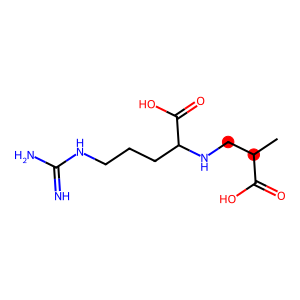

In [9]:
mol = Chem.MolFromSmiles(smiles)
highlight_atoms = [1, 2]
highlight_bonds = []
highlight_color = (1, 0.0, 0.0)  # colors for highlighting

draw_mol = Draw.MolToImage(mol, highlightAtoms=highlight_atoms, highlightBonds=highlight_bonds, highlightColor=highlight_color)
draw_mol

In [ ]:
# Test ProteinEmbeddingLayer

from transformers import AutoTokenizer, AutoModel
prot_embed_layer = ProteinEmbeddingLayer(device=DEVICE)


for seq_batch, smiles_batch, kcat_batch in test_loader:
    prot_emb, prot_mask, symbols = prot_embed_layer(seq_batch, return_symbols=True)
   
    break

### model loading and evaluation

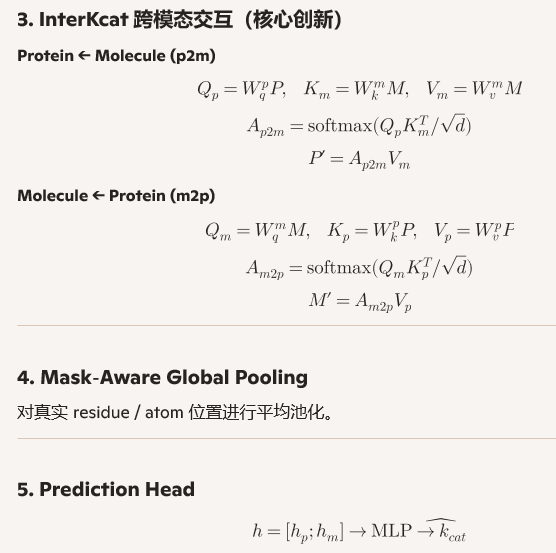

In [5]:
# Load best model and evaluate on test set
model_path = './interkcat_both_lr0.0001_bs128_md256/best_interkcat_model.pth'
model = InterKcat(prot_dim=640, mol_dim=256).to(DEVICE)
model.load_state_dict(torch.load(model_path))
model.eval()

# Hyperparameters
SEED = 1234 # Same with others
BATCH_SIZE = 256

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

all_val_preds, all_val_targets = [], []
with torch.no_grad():
    for seq_batch, smiles_batch, kcat_batch in test_loader:
        kcat_pred = model(
            protein_sequences=seq_batch,
            smiles_list=smiles_batch,
            inter_model="both"
        )

        all_val_preds.append(kcat_pred.cpu().numpy())
        all_val_targets.append(kcat_batch.cpu().numpy())

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


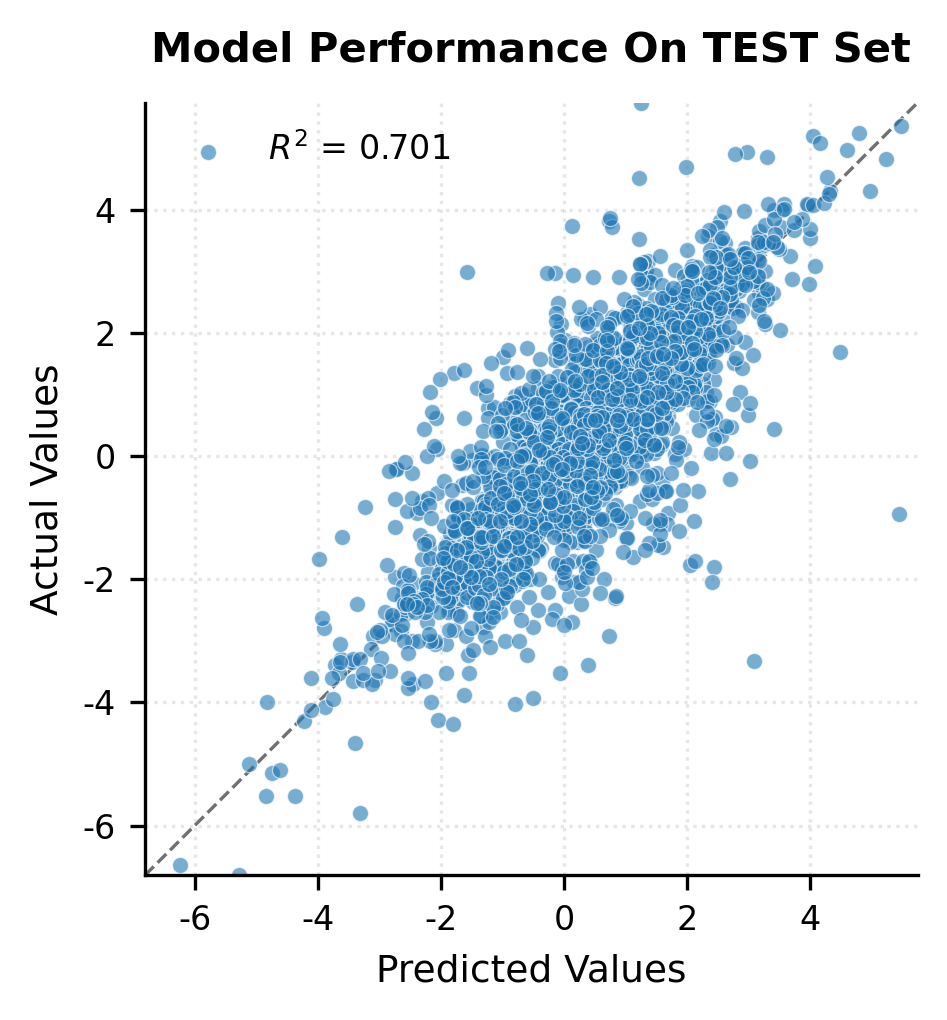

In [6]:
import numpy as np
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

all_val_preds = np.concatenate(all_val_preds)
all_val_targets = np.concatenate(all_val_targets)
r2 = r2_score(all_val_targets, all_val_preds)

# ----Style Settings----
font_list = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in font_list:
    plt.rcParams['font.sans-serif'] = ['Arial']
elif 'Helvetica' in font_list:
    plt.rcParams['font.sans-serif'] = ['Helvetica']
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

# --- Plot ---
fig, ax = plt.subplots(figsize=(4, 3.5), dpi=300)
ax.scatter(all_val_preds, all_val_targets, 
           s=15,
           c='#1f77b4',
           alpha=0.6, 
           edgecolors='white',
           linewidths=0.3,
           label=f'$R^2$ = {r2:.3f}', 
           zorder=2)

lims = [
    np.min([all_val_preds.min(), all_val_targets.min()]),
    np.max([all_val_preds.max(), all_val_targets.max()]),
]
ax.plot(lims, lims, color='#333333', linestyle='--', linewidth=0.8, alpha=0.7, zorder=1)

ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_title('Model Performance On TEST Set', fontsize=10, fontweight='bold', pad=10)
ax.set_xlabel('Predicted Values', fontsize=9)
ax.set_ylabel('Actual Values', fontsize=9)

ax.tick_params(axis='both', which='major', labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.grid(True, linestyle=':', alpha=0.3, zorder=0)

plt.tight_layout()
# plt.savefig("model_performance(TEST).png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

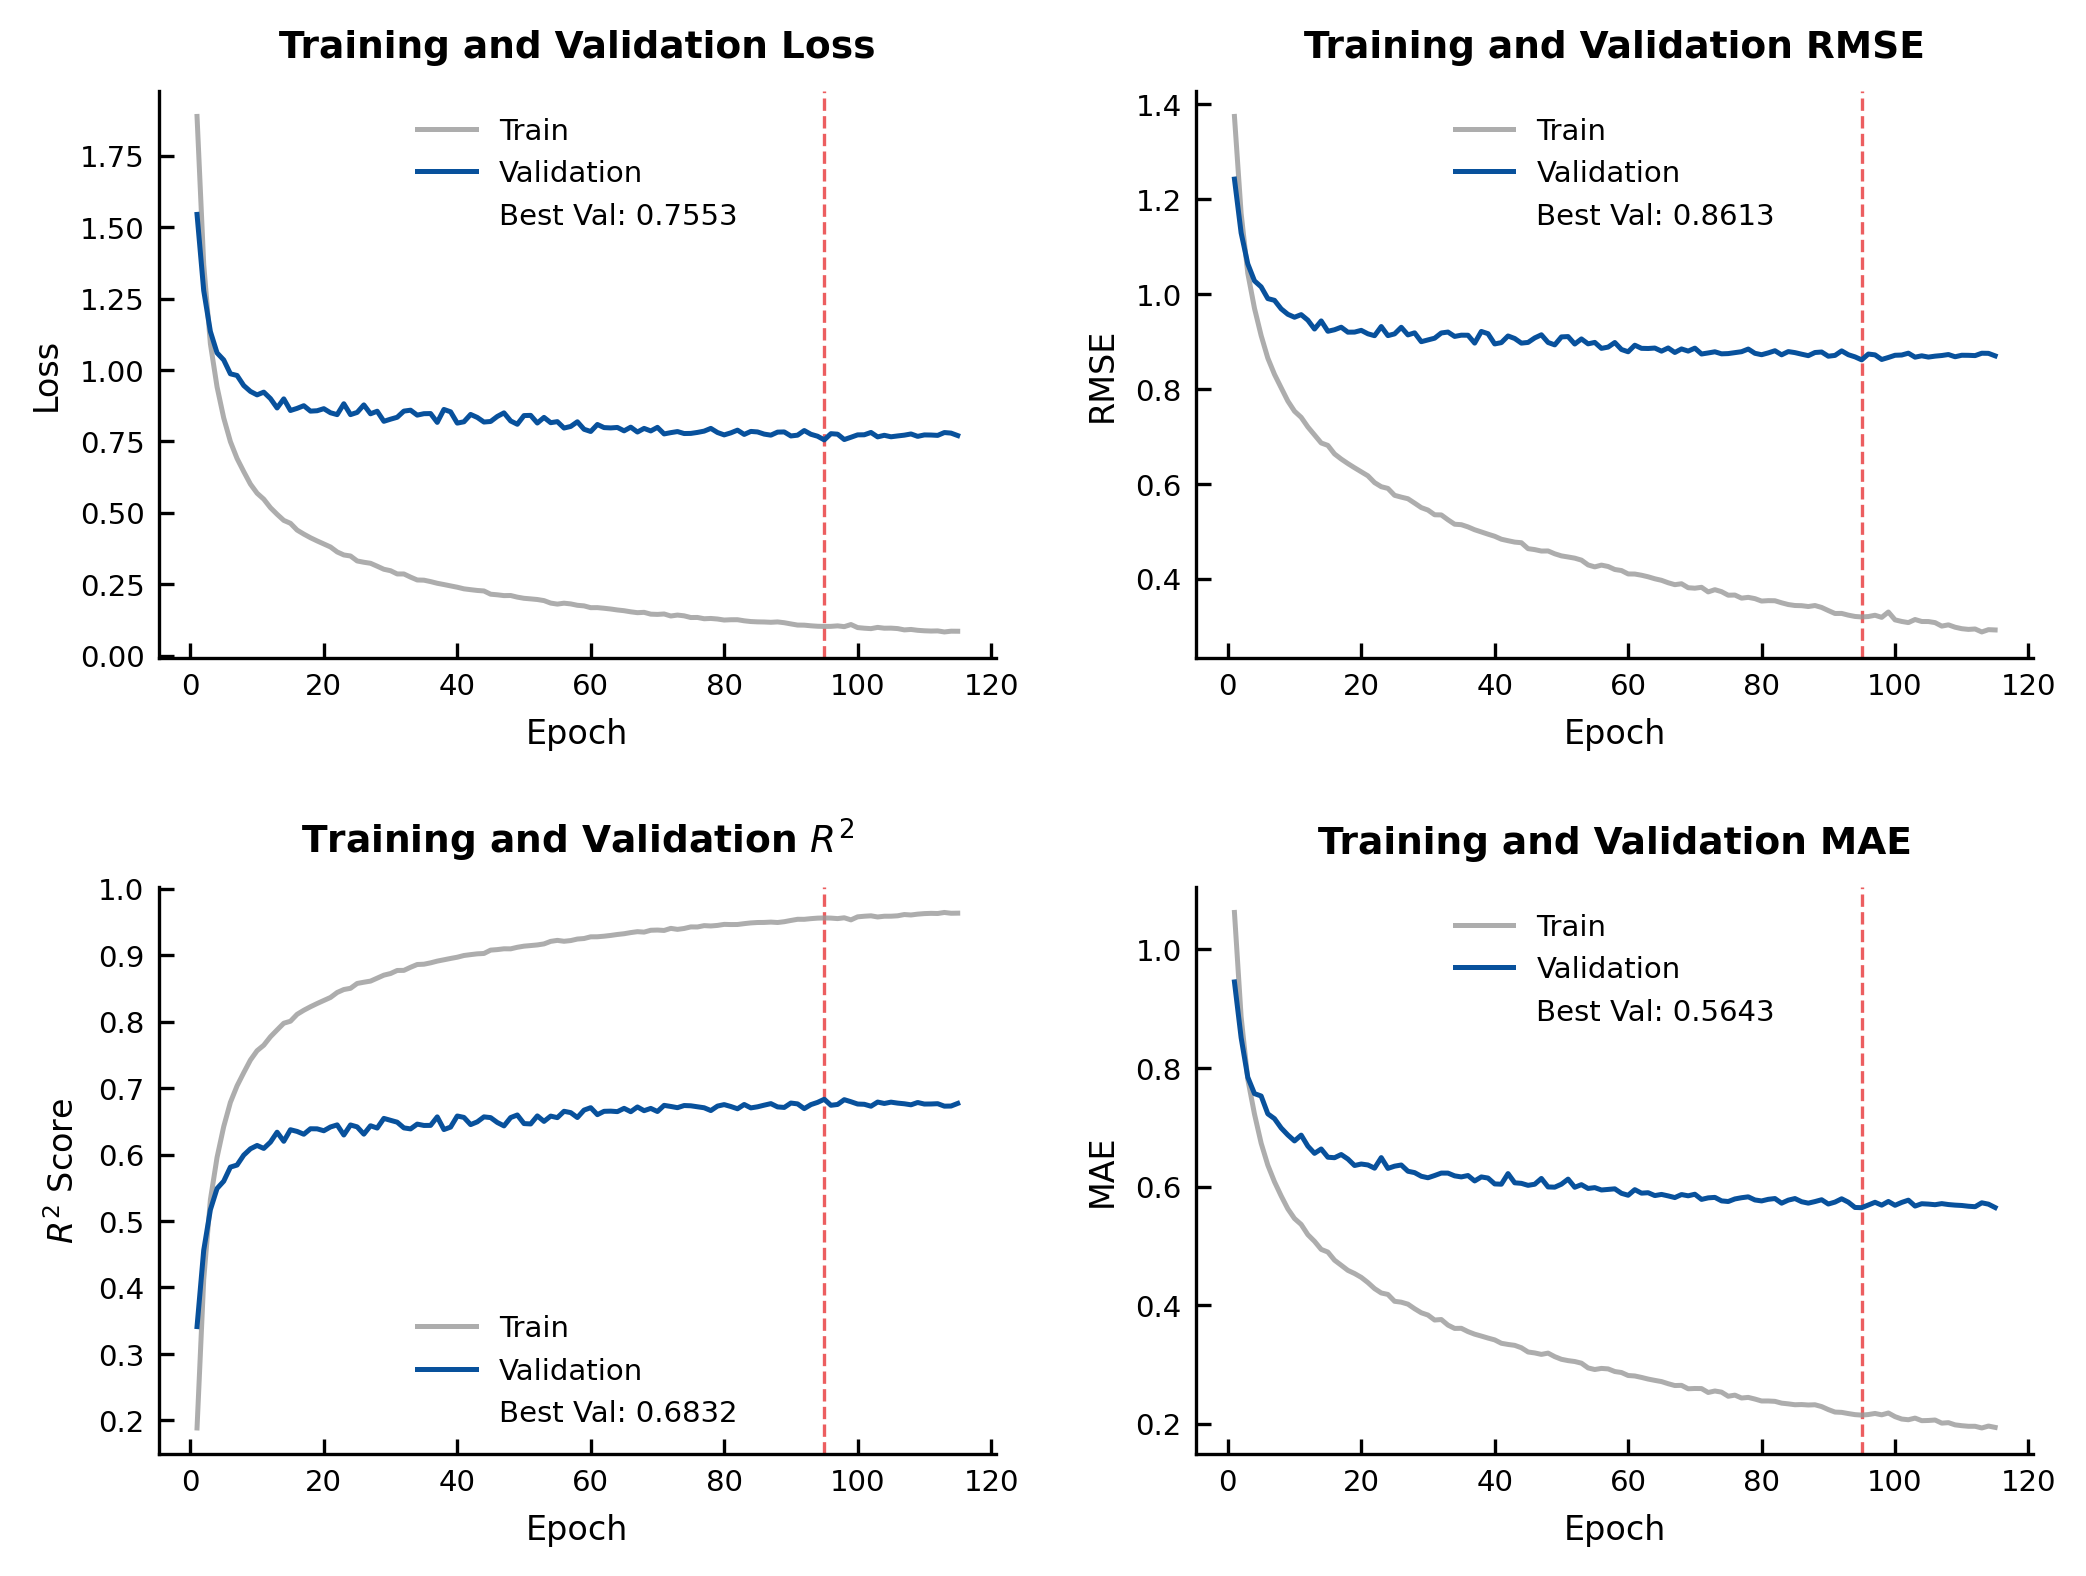

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# --- Style Configuration ---
font_names = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in font_names:
    plt.rcParams['font.sans-serif'] = ['Arial']
elif 'Helvetica' in font_names:
    plt.rcParams['font.sans-serif'] = ['Helvetica']
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42  # Editable text in Illustrator
})

# ---  Data Loading ---
df = pd.read_csv("./interkcat_both_lr0.0001_bs128_md256/training_metrics.csv")
best_epoch_idx = df['Val_R2'].idxmax()
best_row = df.loc[best_epoch_idx]
best_epoch = int(best_row['Epoch'])
df['Epoch'] = df['Epoch'].astype(int)

fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.5), dpi=300)
axes = axes.flatten()
metrics = [
    ('Loss', 'Loss', 'Training and Validation Loss'),
    ('RMSE', 'RMSE', 'Training and Validation RMSE'),
    ('R2', r'$R^2$ Score', r'Training and Validation $R^2$'),
    ('MAE', 'MAE', 'Training and Validation MAE')
]

# Grey for Train, Deep Blue for Validation, Red for best epoch line
c_train = '#999999'
c_val = '#08519c'
c_best_line = '#e41a1c'

for i, (col_base, ylabel, title) in enumerate(metrics):
    ax = axes[i]
    train_col = f'Train_{col_base}'
    val_col = f'Val_{col_base}'
    
    ax.plot(df['Epoch'], df[train_col], label='Train', color=c_train, alpha=0.8)
    ax.plot(df['Epoch'], df[val_col], label='Validation', color=c_val)
    
    ax.axvline(x=best_epoch, color=c_best_line, linestyle='--', linewidth=0.8, alpha=0.7, zorder=0)
    best_val = best_row[val_col]
    ax.plot([], [], ' ', label=f'Best Val: {best_val:.4f}')
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold', pad=8)
    ax.legend(frameon=False, loc='best')

fig.tight_layout(pad=2.0)
# plt.savefig("training_metrics_sci_style.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Model Interpretation: Attention Visualization for a Sample Protein-Molecule Pair

In [11]:
i = 100  # sample index

# === Protein Embedding Info ===
prot_emb, prot_mask, prot_symbols = model.prot_emb([sequences[i]], return_symbols=True)
# prot_mask: (1, L_prot), prot_symbols: List[str] of length L_prot

# === Molecule Embedding Info ===
mol_out = model.mol_emb([smiles_list[i]], return_symbols=True)
# mol_out.atom_mask: (1, L_mol), mol_out.atom_symbols: List[str] of length L_mol

# === Attention Maps from Model Output ===
pred, attn_p2m, attn_m2p = model(
    protein_sequences=[sequences[i]],
    smiles_list=[smiles_list[i]],
    inter_model="both",
    return_attn=True
)

# Remove batch dimension (since batch_size=1)
prot_mask = prot_mask.squeeze(0)          # (L_prot,)
mol_mask = mol_out.atom_mask.squeeze(0)   # (L_mol,)
attn_p2m = attn_p2m.squeeze(0)            # (L_prot, L_mol)
attn_m2p = attn_m2p.squeeze(0)            # (L_mol, L_prot)

# Get real lengths (excluding padding)
real_prot_len = prot_mask.sum().item()
real_mol_len = mol_mask.sum().item()

# Extract valid attention submatrices
attn_p2m_real = attn_p2m[:real_prot_len, :real_mol_len]   # (P, M) Protein → Molecule The "attention" of each amino acid to each molecular atom
attn_m2p_real = attn_m2p[:real_mol_len, :real_prot_len]   # (M, P) Molecule → Protein The "attention" of each molecular atom to each amino acid

# Get corresponding symbols
prot_seq = prot_symbols[0][:real_prot_len]        # List[str], e.g., ['M', 'K', 'T', ...]
mol_atoms = mol_out.atom_symbols[0][:real_mol_len]  # List[str], e.g., ['C', 'O', 'N', ...]

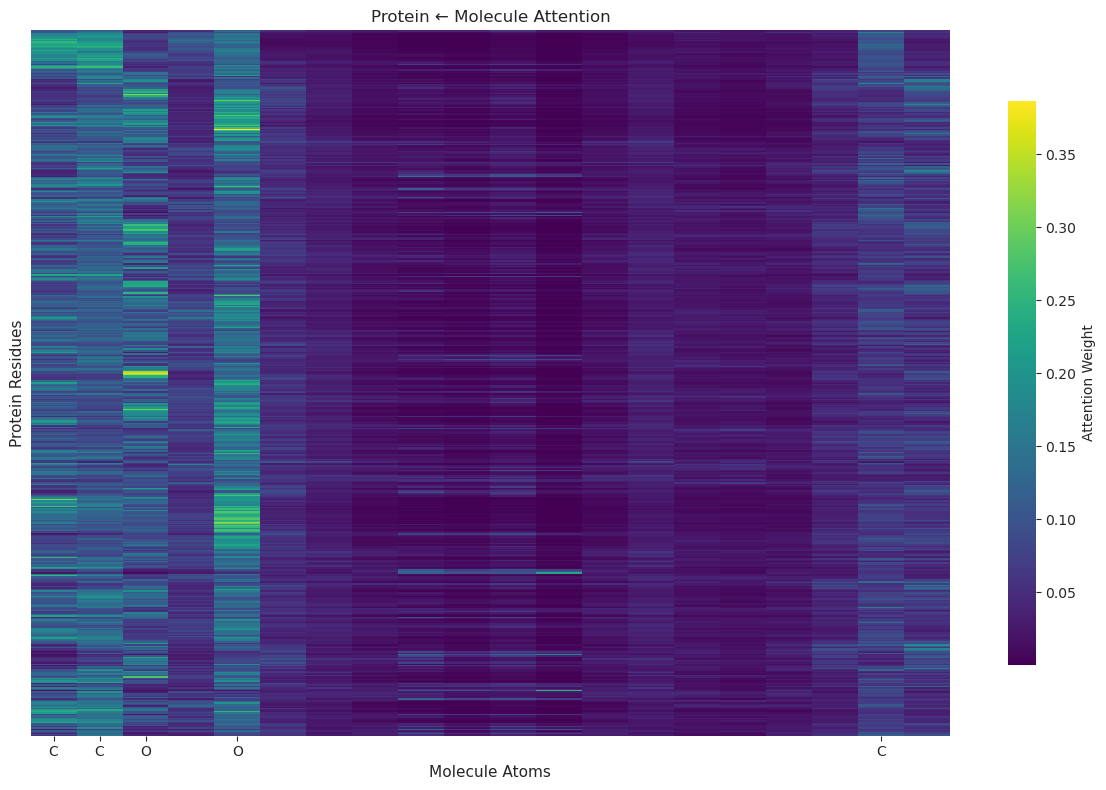

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

attn_real_detached = attn_p2m_real.detach().cpu().numpy()
avg_attn_per_atom = attn_real_detached.mean(axis=0)  # shape: (num_atoms,)
k = min(5, len(avg_attn_per_atom))
top_k_indices = np.argsort(avg_attn_per_atom)[-k:]
top_k_indices = np.sort(top_k_indices)
top_k_labels = [mol_atoms[i] for i in top_k_indices]


plt.figure(figsize=(12, 8))
sns.set_style("ticks")

ax = sns.heatmap(
    attn_real_detached,
    xticklabels=False,          
    yticklabels=False,       
    cmap="viridis",
    cbar_kws={
        'label': 'Attention Weight',
        'shrink': 0.8,      
        'aspect': 20
    },
    linewidths=0,               
    rasterized=True             
)
ax.set_xticks([i + 0.5 for i in top_k_indices])
ax.set_xticklabels(top_k_labels, rotation=0, fontsize=10)

plt.xlabel("Molecule Atoms", fontsize=11)
plt.ylabel("Protein Residues", fontsize=11)
plt.title("Protein ← Molecule Attention", fontsize=12)
plt.tight_layout()
# plt.savefig("protein_to_molecule_attention_real.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

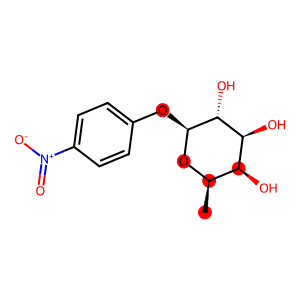

In [20]:
from rdkit.Chem import Draw

mol = Chem.MolFromSmiles(smiles_list[i])
highlight_atoms = top_k_indices.tolist()
highlight_bonds = []
highlight_color = (1, 0.0, 0.0)  # colors for highlighting

draw_mol = Draw.MolToImage(mol, highlightAtoms=highlight_atoms, highlightBonds=highlight_bonds, highlightColor=highlight_color)
draw_mol

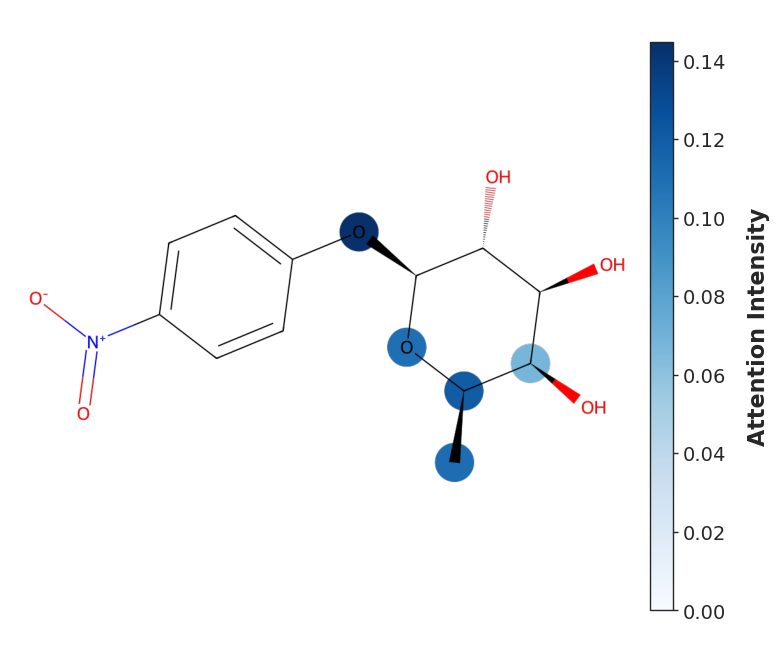

In [22]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import io
from PIL import Image
import matplotlib.font_manager as fm

# --- Style Configuration ---
font_list = [f.name for f in fm.fontManager.ttflist]
if 'Arial' in font_list:
    plt.rcParams['font.sans-serif'] = ['Arial']
elif 'Helvetica' in font_list:
    plt.rcParams['font.sans-serif'] = ['Helvetica']
else:
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.2 
plt.rcParams['font.size'] = 14

# Load SMILES and compute attention weights
smiles = smiles_list[i]
mol = Chem.MolFromSmiles(smiles)
if not mol:
    raise ValueError("Invalid SMILES string.")

# Explicitly generate 2D coordinates for standard orientation
rdDepictor.Compute2DCoords(mol)

# Color Mapping 'Reds', 'OrRd', 'Purples', 'Blues'
cmap_name = 'Blues' 
cmap = plt.get_cmap(cmap_name)

# Find the maximum weight among top-K to scale colors appropriately
max_weight = max([float(avg_attn_per_atom[idx]) for idx in top_k_indices]) if len(top_k_indices) > 0 else 1.0
norm = Normalize(vmin=0, vmax=max_weight)

# Build explicit highlight dictionaries for RDKit
highlight_atoms = []
highlight_colors = {}
highlight_radii = {}

for idx in top_k_indices:
    py_idx = int(idx) 
    weight = float(avg_attn_per_atom[py_idx])    
    highlight_atoms.append(py_idx)
    rgba = cmap(norm(weight))
    highlight_colors[py_idx] = (float(rgba[0]), float(rgba[1]), float(rgba[2]))
    highlight_radii[py_idx] = 0.4

# Drawing options
d2d_opts = Draw.MolDrawOptions()
d2d_opts.minFontSize = 18
d2d_opts.maxFontSize = 28
d2d_opts.bondLineWidth = 2.0
d2d_opts.padding = 0.02


d2d_opts.clearBackground = False 
d2d = Draw.MolDraw2DCairo(1000, 1000) 
d2d.SetDrawOptions(d2d_opts)

d2d.DrawMolecule(
    mol, 
    highlightAtoms=highlight_atoms, 
    highlightAtomColors=highlight_colors, 
    highlightBonds=[], # Keep empty to avoid coloring the bonds between atoms
    highlightAtomRadii=highlight_radii
)
d2d.FinishDrawing()
png_data = d2d.GetDrawingText()
pil_image = Image.open(io.BytesIO(png_data))
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(pil_image)
ax.axis('off')

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([]) 
cbar = plt.colorbar(sm, ax=ax, fraction=0.045, pad=0.01, aspect=25, shrink=0.75)
cbar.ax.tick_params(labelsize=14, direction='out', width=1.0) 
cbar.outline.set_linewidth(1.0)
cbar.set_label('Attention Intensity', fontsize=16, labelpad=15, fontweight='bold')

plt.tight_layout()
# plt.savefig("mol_attention_map.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

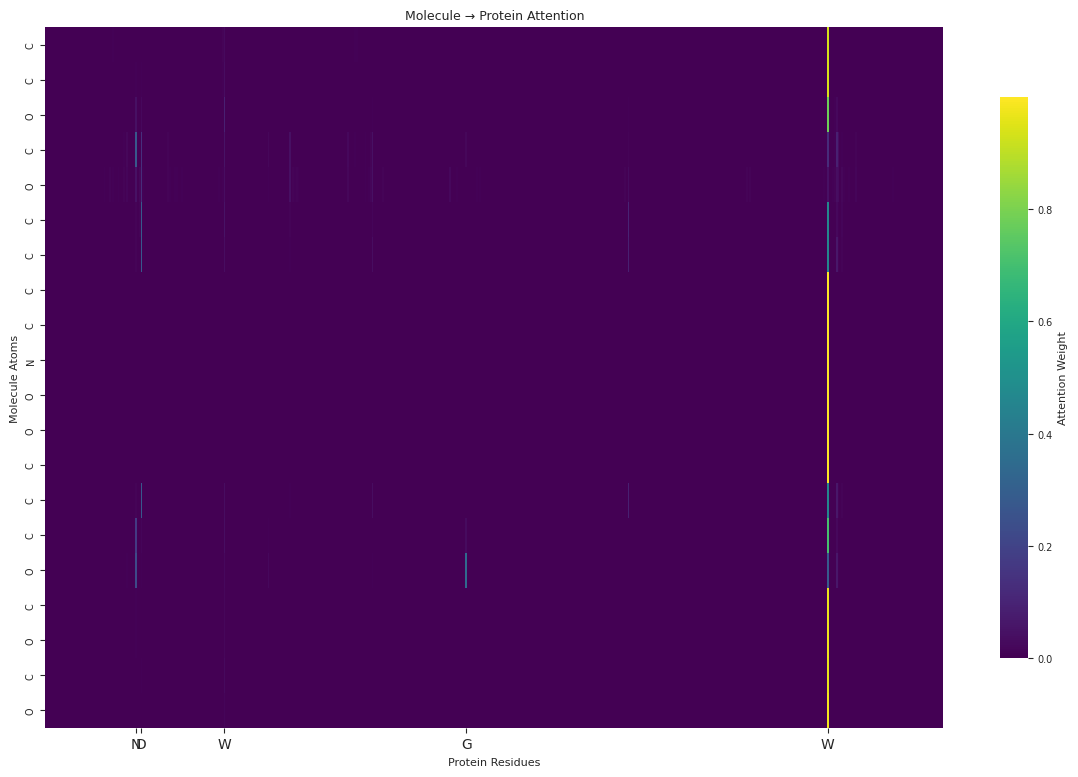

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

attn_real_detached = attn_m2p_real.detach().cpu().numpy()
avg_attn_per_residue = attn_real_detached.mean(axis=0)  # shape: (num_residues,)
k = min(5, len(avg_attn_per_residue))
top_k_indices = np.argsort(avg_attn_per_residue)[-k:]
top_k_indices = np.sort(top_k_indices)
top_k_labels = [prot_seq[i] for i in top_k_indices]

plt.figure(figsize=(12, 8))
sns.set_style("ticks")

ax = sns.heatmap(
    attn_real_detached,
    xticklabels=False,
    yticklabels=mol_atoms,
    cmap="viridis",
    cbar_kws={
        'label': 'Attention Weight',
        'shrink': 0.8,      
        'aspect': 20
    },
    linewidths=0,               
    rasterized=True
)

ax.set_xticks([i + 0.5 for i in top_k_indices])
ax.set_xticklabels(top_k_labels, rotation=0, fontsize=10)

plt.xlabel("Protein Residues")
plt.ylabel("Molecule Atoms")
plt.title("Molecule → Protein Attention")
plt.tight_layout()
# plt.savefig("molecule_to_protein_attention_real.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Statistical Analysis

In [25]:
import numpy as np
from collections import Counter
from tqdm import tqdm

threshold = 0.50

# High-Attention & Background
high_seq_symbols = []  # To store high-attention amino acids
high_mol_symbols = []  # To store high-attention atoms

bg_seq_symbols = []    # To store ALL amino acids (Background)
bg_mol_symbols = []    # To store ALL atoms (Background)

def get_top_p_elements(scores, symbols, threshold):
    sorted_idx = np.argsort(scores)[::-1]
    cum_scores = np.cumsum(scores[sorted_idx])
    cutoff = np.searchsorted(cum_scores, threshold) + 1
    top_idx = np.sort(sorted_idx[:cutoff])
    return [symbols[i] for i in top_idx]

print("Processing attention matrices for all samples...")

for i in tqdm(range(len(sequences)), desc="Processing samples"):
    prot_emb, prot_mask, prot_symbols = model.prot_emb([sequences[i]], return_symbols=True)
    mol_out = model.mol_emb([smiles_list[i]], return_symbols=True)
    
    pred, attn_p2m, attn_m2p = model(
        protein_sequences=[sequences[i]], smiles_list=[smiles_list[i]],
        inter_model="both", return_attn=True
    )

    prot_mask = prot_mask.squeeze(0)
    mol_mask = mol_out.atom_mask.squeeze(0)
    attn_p2m = attn_p2m.squeeze(0)
    attn_m2p = attn_m2p.squeeze(0)

    real_prot_len = prot_mask.sum().item()
    real_mol_len = mol_mask.sum().item()

    attn_p2m_real = attn_p2m[:real_prot_len, :real_mol_len]
    attn_m2p_real = attn_m2p[:real_mol_len, :real_prot_len]

    prot_seq = prot_symbols[0][:real_prot_len]
    mol_atoms = mol_out.atom_symbols[0][:real_mol_len]

    attn_m2p_np = attn_m2p_real.detach().cpu().numpy()
    attn_p2m_np = attn_p2m_real.detach().cpu().numpy()
    aa_scores_norm = attn_m2p_np.sum(axis=0) / attn_m2p_np.sum()
    mol_scores_norm = attn_p2m_np.sum(axis=0) / attn_p2m_np.sum()

    top_aas = get_top_p_elements(aa_scores_norm, prot_seq, threshold)
    top_atoms = get_top_p_elements(mol_scores_norm, mol_atoms, threshold)
    
    # Append to respective lists
    high_seq_symbols.extend(top_aas)
    high_mol_symbols.extend(top_atoms)
    
    bg_seq_symbols.extend(prot_seq)
    bg_mol_symbols.extend(mol_atoms)

Processing attention matrices for all samples...


Processing samples: 100%|█████████████████| 34140/34140 [18:04<00:00, 31.49it/s]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chisquare
from scipy.interpolate import make_interp_spline

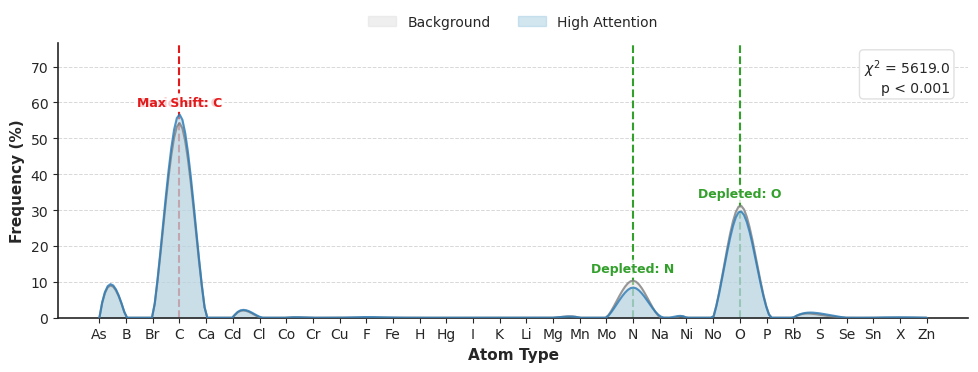

In [35]:
bg_list = bg_mol_symbols
high_list = high_mol_symbols

# count frequencies
bg_counts = Counter(bg_list)
high_counts = Counter(high_list)

unique_symbols = sorted(list(set(bg_list)))

total_bg = sum(bg_counts.values())
total_high = sum(high_counts.values())

bg_freqs = []
high_freqs = []
f_obs = [] 
f_exp = [] 

for sym in unique_symbols:
    bg_freqs.append((bg_counts[sym] / total_bg) * 100 if total_bg > 0 else 0)
    high_freqs.append((high_counts[sym] / total_high) * 100 if total_high > 0 else 0)
    
    observed = high_counts[sym]
    expected = (bg_counts[sym] / total_bg) * total_high
    f_obs.append(observed)
    f_exp.append(expected if expected > 0 else 1e-5)

# chi-square test
chi2_stat, p_value = chisquare(f_obs=f_obs, f_exp=f_exp)
    
# Find symbol with max frequency difference
freq_diffs = np.abs(np.array(high_freqs) - np.array(bg_freqs))
max_diff_idx = np.argmax(freq_diffs)
max_diff_sym = unique_symbols[max_diff_idx]

x = np.arange(len(unique_symbols))
x_smooth = np.linspace(x.min(), x.max(), 300)
spline_bg = make_interp_spline(x, bg_freqs, k=3)
bg_freqs_smooth = np.clip(spline_bg(x_smooth), 0, None)
spline_high = make_interp_spline(x, high_freqs, k=3)
high_freqs_smooth = np.clip(spline_high(x_smooth), 0, None)


fig, ax = plt.subplots(figsize=(10, 4)) 
color_bg, fill_bg = '#808080', '#E0E0E0'
color_high, fill_high = '#2C7BB6', '#A6CEE3'

ax.fill_between(x_smooth, 0, bg_freqs_smooth, color=fill_bg, alpha=0.5, zorder=2, label='Background')
ax.fill_between(x_smooth, 0, high_freqs_smooth, color=fill_high, alpha=0.5, zorder=2, label='High Attention')
ax.plot(x_smooth, bg_freqs_smooth, color=color_bg, linewidth=1.5, zorder=3, alpha=0.8)
ax.plot(x_smooth, high_freqs_smooth, color=color_high, linewidth=1.5, zorder=3, alpha=0.8)

# custom annotations
depleted_syms = ['N','O']
enriched_syms = ['C']

color_depleted = '#33A02C'   # Depleted
color_enriched = '#E31A1C'   # Enriched

marked_indices = set()

# Depleted symbols (N, O)
for sym in depleted_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        ax.axvline(x=idx, color=color_depleted, linestyle='--', linewidth=1.5, zorder=1)
        y_max = max(high_freqs[idx], bg_freqs[idx])
        ax.text(idx, y_max + 1.5, f"Depleted: {sym}", 
                color=color_depleted, ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)
        marked_indices.add(idx)

# Enriched symbols (C)
for sym in enriched_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        ax.axvline(x=idx, color=color_enriched, linestyle='--', linewidth=1.5, zorder=1)
        y_max = max(high_freqs[idx], bg_freqs[idx])
        ax.text(idx, y_max + 1.5, f"Enriched: {sym}", 
                color=color_enriched, ha='center', va='bottom', fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)
        marked_indices.add(idx)

y_max_at_diff = max(high_freqs[max_diff_idx], bg_freqs[max_diff_idx])
ax.text(max_diff_idx, y_max_at_diff + 1.5, f"Max Shift: {max_diff_sym}", 
        color="#E31A1C", ha='center', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)

ax.set_ylim(0, max(max(high_freqs), max(bg_freqs)) * 1.35) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=10)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)

ax.set_ylabel('Frequency (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Atom Type', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(unique_symbols, fontsize=10)
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=10)

p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
stats_text = f"$\\chi^2$ = {chi2_stat:.1f}\n{p_text}"
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
        ha='right', va='top', fontsize=10, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#DDDDDD", alpha=0.9), zorder=6)

plt.tight_layout()
title = "Atom Type Distribution in High-Attention vs Background"
filename_base = title.replace(' ', '_').replace(':', '').lower()
plt.savefig(f"{filename_base}.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

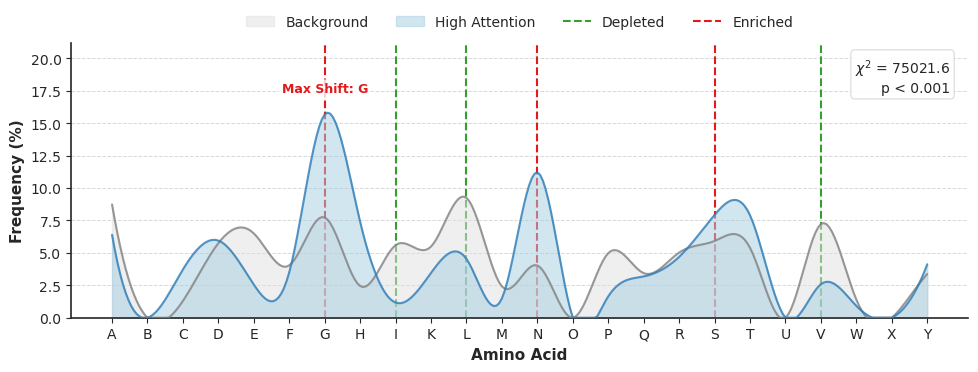

In [33]:
bg_list = bg_seq_symbols
high_list = high_seq_symbols

# count frequencies
bg_counts = Counter(bg_list)
high_counts = Counter(high_list)

unique_symbols = sorted(list(set(bg_list)))

total_bg = sum(bg_counts.values())
total_high = sum(high_counts.values())

bg_freqs = []
high_freqs = []
f_obs = [] 
f_exp = [] 

for sym in unique_symbols:
    bg_freqs.append((bg_counts[sym] / total_bg) * 100 if total_bg > 0 else 0)
    high_freqs.append((high_counts[sym] / total_high) * 100 if total_high > 0 else 0)
    
    observed = high_counts[sym]
    expected = (bg_counts[sym] / total_bg) * total_high
    f_obs.append(observed)
    f_exp.append(expected if expected > 0 else 1e-5)

# chi-square test
chi2_stat, p_value = chisquare(f_obs=f_obs, f_exp=f_exp)
    
# Find symbol with max frequency difference
freq_diffs = np.abs(np.array(high_freqs) - np.array(bg_freqs))
max_diff_idx = np.argmax(freq_diffs)
max_diff_sym = unique_symbols[max_diff_idx]

x = np.arange(len(unique_symbols))
x_smooth = np.linspace(x.min(), x.max(), 300)
spline_bg = make_interp_spline(x, bg_freqs, k=3)
bg_freqs_smooth = np.clip(spline_bg(x_smooth), 0, None)
spline_high = make_interp_spline(x, high_freqs, k=3)
high_freqs_smooth = np.clip(spline_high(x_smooth), 0, None)


fig, ax = plt.subplots(figsize=(10, 4)) 
color_bg, fill_bg = '#808080', '#E0E0E0'
color_high, fill_high = '#2C7BB6', '#A6CEE3'

ax.fill_between(x_smooth, 0, bg_freqs_smooth, color=fill_bg, alpha=0.5, zorder=2, label='Background')
ax.fill_between(x_smooth, 0, high_freqs_smooth, color=fill_high, alpha=0.5, zorder=2, label='High Attention')
ax.plot(x_smooth, bg_freqs_smooth, color=color_bg, linewidth=1.5, zorder=3, alpha=0.8)
ax.plot(x_smooth, high_freqs_smooth, color=color_high, linewidth=1.5, zorder=3, alpha=0.8)

# custom annotations
depleted_syms = ['I', 'L', 'V']
enriched_syms = ['N', 'G', 'S']

color_depleted = '#33A02C'   # Depleted
color_enriched = '#E31A1C'   # Enriched

marked_indices = set()

# Depleted symbols (I, L, V)
depleted_labeled = False
for sym in depleted_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        label = 'Depleted' if not depleted_labeled else None
        ax.axvline(x=idx, color=color_depleted, linestyle='--', linewidth=1.5, zorder=1, label=label)
        depleted_labeled = True
        marked_indices.add(idx)

# Enriched symbols (N, G, S)
enriched_labeled = False
for sym in enriched_syms:
    if sym in unique_symbols:
        idx = unique_symbols.index(sym)
        label = 'Enriched' if not enriched_labeled else None
        ax.axvline(x=idx, color=color_enriched, linestyle='--', linewidth=1.5, zorder=1, label=label)
        enriched_labeled = True
        marked_indices.add(idx)

# Max difference annotation
y_max_at_diff = max(high_freqs[max_diff_idx], bg_freqs[max_diff_idx])
ax.text(max_diff_idx, y_max_at_diff + 1.5, f"Max Shift: {max_diff_sym}", 
        color='#E31A1C', ha='center', va='bottom', fontsize=9, fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.8), zorder=5)

ax.set_ylim(0, max(max(high_freqs), max(bg_freqs)) * 1.35) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=10)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)

ax.set_ylabel('Frequency (%)', fontsize=11, fontweight='bold')
ax.set_xlabel('Amino Acid', fontsize=11, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(unique_symbols, fontsize=10)

ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4, fontsize=10)

p_text = "p < 0.001" if p_value < 0.001 else f"p = {p_value:.3f}"
stats_text = f"$\\chi^2$ = {chi2_stat:.1f}\n{p_text}"
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, 
        ha='right', va='top', fontsize=10, 
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#DDDDDD", alpha=0.9), zorder=6)

plt.tight_layout()
title = "Amino Acid Distribution in High-Attention vs Background"
filename_base = title.replace(' ', '_').replace(':', '').lower()
plt.savefig(f"{filename_base}.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

### Group Analysis by EC Number

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('EITLEM_KCAT.csv')
# EC class
df['EC_Main_Class'] = df['ECNumber'].astype(str).apply(lambda x: x.split('.')[0])
df['EC_Main_Class'] = 'EC ' + df['EC_Main_Class']
# df.to_csv('EITLEM_KCAT_grouped.csv', index=False)

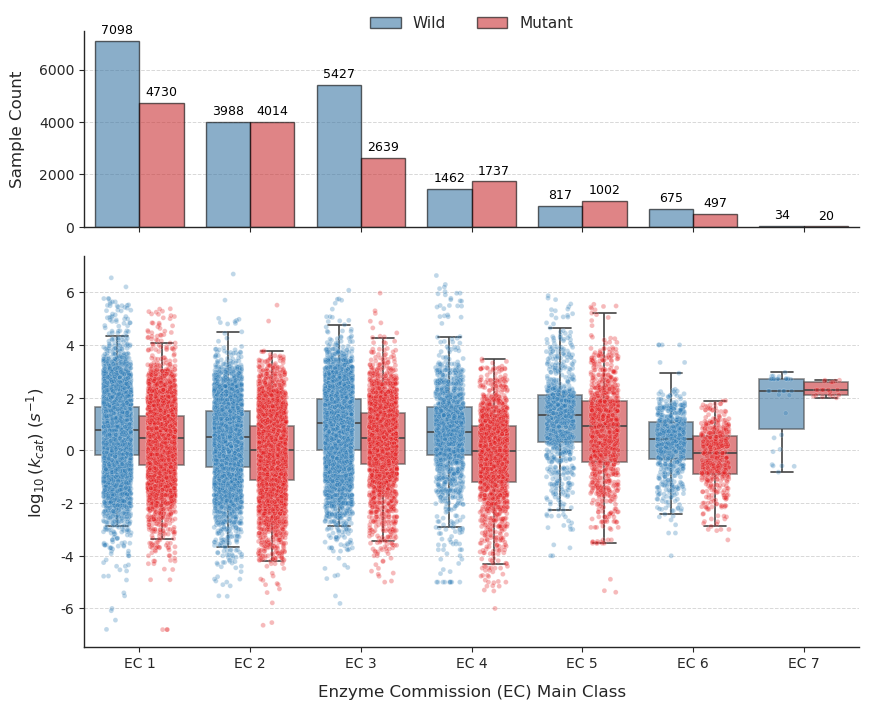

In [37]:
plot_df = df.dropna(subset=['EC_Main_Class', 'Value', 'type']).copy()
valid_ecs = [f"EC {i}" for i in range(1, 8)]
plot_df = plot_df[plot_df['EC_Main_Class'].isin(valid_ecs)]
plot_df = plot_df[plot_df['Value'] > 0]
plot_df['Log_kcat'] = np.log10(plot_df['Value'])
plot_df['type'] = plot_df['type'].str.capitalize()

# --- Style Configuration ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.0

palette = {'Wild': '#2C7BB6', 'Mutant': '#E31A1C'}
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 8),
                               gridspec_kw={'height_ratios': [1, 2]}, sharex=True)

# Plot 1: Sample Counts per EC Class
sns.countplot(
    x='EC_Main_Class', hue='type', data=plot_df, 
    order=valid_ecs, palette=palette, ax=ax1, 
    edgecolor='black', linewidth=1.0, alpha=0.6
)

ax1.set_ylabel('Sample Count', fontsize=12, labelpad=10)
ax1.set_xlabel('')
handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles[:2], labels[:2], frameon=False, loc='upper center', 
           bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize=11)

for p in ax1.patches:
    height = p.get_height()
    if np.isnan(height) or height == 0:
        continue
    ax1.annotate(f'{int(height)}', 
                 (p.get_x() + p.get_width() / 2., height), 
                 ha='center', va='bottom', fontsize=9, color='black', 
                 xytext=(0, 3), textcoords='offset points')

# Plot 2: kcat Distribution per EC Class
sns.boxplot(
    x='EC_Main_Class', y='Log_kcat', hue='type', data=plot_df, 
    order=valid_ecs, palette=palette, fliersize=0, 
    linewidth=1.2, ax=ax2, boxprops=dict(alpha=0.6)
)

sns.stripplot(
    x='EC_Main_Class', y='Log_kcat', hue='type', data=plot_df, 
    order=valid_ecs, palette=palette, dodge=True, alpha=0.3, 
    size=3.5, jitter=0.25, ax=ax2, edgecolor='white', linewidth=0.3
)

ax2.set_ylabel(r'$\log_{10}(k_{cat})$ ($s^{-1}$)', fontsize=12, labelpad=10)
ax2.set_xlabel('Enzyme Commission (EC) Main Class', fontsize=12, labelpad=10)
if ax2.get_legend() is not None:
    ax2.get_legend().remove()

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=10)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)

plt.subplots_adjust(hspace=0.1)
filename = "kcat_distribution_and_counts_ec"
# plt.savefig(f"{filename}.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

In [38]:
from tqdm import tqdm

def calculate_normalized_entropy(scores_1d):
    length = len(scores_1d)
    if length <= 1:
        return 0.0
    probs = scores_1d / (scores_1d.sum() + 1e-9)
    probs = probs[probs > 1e-9]
    raw_entropy = -np.sum(probs * np.log2(probs))
    return raw_entropy / np.log2(length)

Entropy_seq_list = []
Entropy_mol_list = []

for i in tqdm(range(len(sequences)), desc="Processing samples"):
    prot_emb, prot_mask, prot_symbols = model.prot_emb([sequences[i]], return_symbols=True)
    mol_out = model.mol_emb([smiles_list[i]], return_symbols=True)
    
    pred, attn_p2m, attn_m2p = model(
        protein_sequences=[sequences[i]], smiles_list=[smiles_list[i]],
        inter_model="both", return_attn=True
    )

    prot_mask = prot_mask.squeeze(0)
    mol_mask = mol_out.atom_mask.squeeze(0)
    attn_p2m = attn_p2m.squeeze(0)
    attn_m2p = attn_m2p.squeeze(0)

    real_prot_len = prot_mask.sum().item()
    real_mol_len = mol_mask.sum().item()

    attn_p2m_real = attn_p2m[:real_prot_len, :real_mol_len].detach().cpu().numpy() # (P, M)
    attn_m2p_real = attn_m2p[:real_mol_len, :real_prot_len].detach().cpu().numpy() # (M, P)

    # Molecule Entropy)
    mol_scores = attn_p2m_real.sum(axis=0)
    entropy_mol = calculate_normalized_entropy(mol_scores)
    
    # Sequence Entropy
    aa_scores = attn_m2p_real.sum(axis=0)
    entropy_seq = calculate_normalized_entropy(aa_scores)

    Entropy_seq_list.append(entropy_seq)
    Entropy_mol_list.append(entropy_mol)

df['Entropy_seq_norm'] = Entropy_seq_list
df['Entropy_mol_norm'] = Entropy_mol_list

Processing samples: 100%|█████████████████| 34140/34140 [18:05<00:00, 31.46it/s]


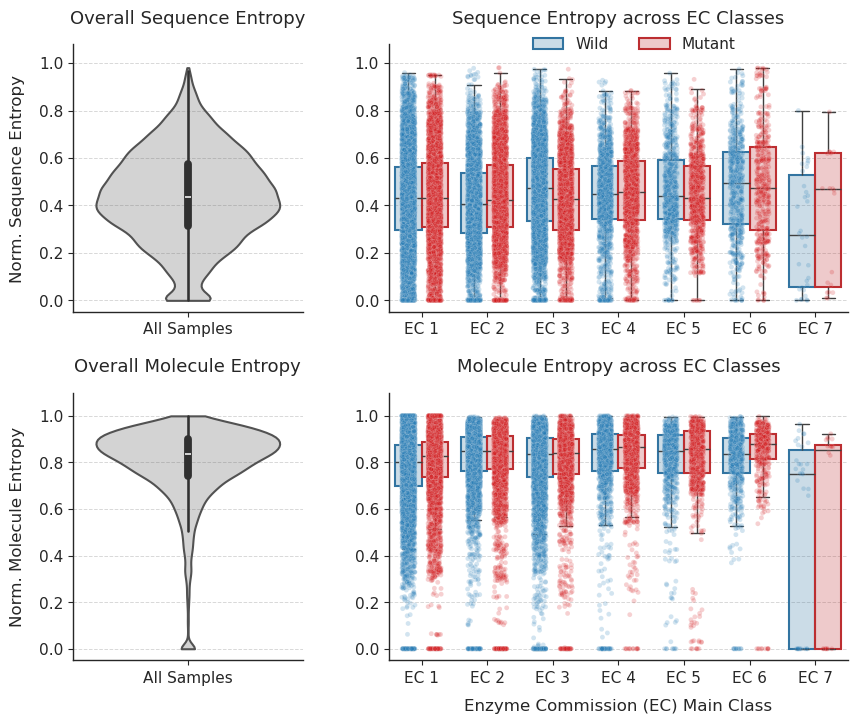

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.collections as collections

df = pd.read_csv('EITLEM_KCAT_with_entropy.csv')
plot_df = df.dropna(subset=['EC_Main_Class', 'type', 'Entropy_seq_norm', 'Entropy_mol_norm']).copy()
valid_ecs = [f"EC {i}" for i in range(1, 8)]
plot_df = plot_df[plot_df['EC_Main_Class'].isin(valid_ecs)]
plot_df['type'] = plot_df['type'].str.capitalize()
plot_df['Overall'] = 'All Samples'

# --- Style Configuration ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.linewidth'] = 1.0

palette_dark = {'Wild': '#1F78B4', 'Mutant': "#D3171AA9"}
color_overall_dark = '#525252'

def apply_custom_fill_edge(ax):
    for patch in ax.patches:
        color = patch.get_facecolor()
        patch.set_facecolor((color[0], color[1], color[2], 0.25))
        patch.set_edgecolor((color[0], color[1], color[2], 1.0))
        patch.set_linewidth(1.5)
        
    for collection in ax.collections:
        if isinstance(collection, collections.PolyCollection):
            colors = collection.get_facecolor()
            if len(colors) > 0:
                color = colors[0]
                collection.set_facecolor((color[0], color[1], color[2], 0.25))
                collection.set_edgecolor((color[0], color[1], color[2], 1.0))
                collection.set_linewidth(1.5)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8), 
                         gridspec_kw={'width_ratios': [1, 2], 'wspace': 0.25, 'hspace': 0.3})

y_max_seq = plot_df['Entropy_seq_norm'].max()
y_max_mol = plot_df['Entropy_mol_norm'].max()

# Protein Sequence Entropy
sns.violinplot(x='Overall', y='Entropy_seq_norm', data=plot_df,
               color=color_overall_dark, inner='box', cut=0, ax=axes[0, 0])
apply_custom_fill_edge(axes[0, 0])

axes[0, 0].set_title('Overall Sequence Entropy', fontsize=13, pad=15)
axes[0, 0].set_ylabel('Norm. Sequence Entropy', fontsize=12, labelpad=10)
axes[0, 0].set_xlabel('')

# EC-wise Seq Entropy
sns.boxplot(x='EC_Main_Class', y='Entropy_seq_norm', hue='type', data=plot_df, 
            order=valid_ecs, palette=palette_dark, fliersize=0, ax=axes[0, 1])
apply_custom_fill_edge(axes[0, 1])
sns.stripplot(x='EC_Main_Class', y='Entropy_seq_norm', hue='type', data=plot_df, 
              order=valid_ecs, palette=palette_dark, dodge=True, alpha=0.2, 
              size=3.5, jitter=0.2, ax=axes[0, 1], edgecolor='white', linewidth=0.3)

axes[0, 1].set_title('Sequence Entropy across EC Classes', fontsize=13, pad=15)
axes[0, 1].set_ylabel('')
axes[0, 1].set_xlabel('')


handles, labels = axes[0, 1].get_legend_handles_labels()
axes[0, 1].legend(handles[:2], labels[:2], frameon=False, fontsize=11, ncol = 2, loc=[0.3, 0.95])

# Substrate Molecule Entropy
sns.violinplot(x='Overall', y='Entropy_mol_norm', data=plot_df,
               color=color_overall_dark, inner='box', cut=0, ax=axes[1, 0])
apply_custom_fill_edge(axes[1, 0])

axes[1, 0].set_title('Overall Molecule Entropy', fontsize=13, pad=15)
axes[1, 0].set_ylabel('Norm. Molecule Entropy', fontsize=12, labelpad=10)
axes[1, 0].set_xlabel('')

# EC-wise Mol Entropy
sns.boxplot(x='EC_Main_Class', y='Entropy_mol_norm', hue='type', data=plot_df, 
            order=valid_ecs, palette=palette_dark, fliersize=0, ax=axes[1, 1])
apply_custom_fill_edge(axes[1, 1])
sns.stripplot(x='EC_Main_Class', y='Entropy_mol_norm', hue='type', data=plot_df, 
              order=valid_ecs, palette=palette_dark, dodge=True, alpha=0.2, 
              size=3.5, jitter=0.2, ax=axes[1, 1], edgecolor='white', linewidth=0.3)

axes[1, 1].set_title('Molecule Entropy across EC Classes', fontsize=13, pad=15)
axes[1, 1].set_ylabel('')
axes[1, 1].set_xlabel('Enzyme Commission (EC) Main Class', fontsize=12, labelpad=10)

if axes[1, 1].get_legend() is not None:
    axes[1, 1].get_legend().remove()

for i in range(2):
    for j in range(2):
        ax = axes[i, j]
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='both', which='both', direction='out', top=False, right=False, labelsize=11)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle='--', color='gray', alpha=0.3, linewidth=0.7)
        
        if i == 0: ax.set_ylim(-0.05, y_max_seq * 1.1)
        if i == 1: ax.set_ylim(-0.05, y_max_mol * 1.1)

filename = "entropy_distribution_aesthetic"
# plt.savefig(f"{filename}.png", dpi=600, bbox_inches='tight', transparent=True)b
plt.show()

### Sequence-pairs level analysis

In [10]:
import pandas as pd
from difflib import SequenceMatcher
from tqdm import tqdm
from rdkit import Chem
from Bio.Align import PairwiseAligner
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = pd.read_csv('EITLEM_KCAT_with_entropy.csv')
df['Smiles'] = df['Smiles'].apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s)))

In [ ]:
# Function to count mutation sites based on the 'Mutations' column
def count_mutation_sites(val):
    if pd.isna(val) or val == 'No WT available':
        return pd.NA
    if val == 'WT':
        return 0
    return str(val).count(';') + 1

In [73]:
# parameters
global_aligner = PairwiseAligner()
global_aligner.mode = 'global'
global_aligner.match_score = 2
global_aligner.mismatch_score = -1
global_aligner.open_gap_score = -10
global_aligner.extend_gap_score = -0.5

def extract_mutations_biopython(wt_seq, mut_seq, aligner=global_aligner):
    if pd.isna(wt_seq) or pd.isna(mut_seq):
        return "Invalid Sequence"
    if wt_seq == mut_seq:
        return "No Change"
    
    try:
        alignment = aligner.align(wt_seq, mut_seq)[0]
        seqA = str(alignment[0]) # Aligned WT
        seqB = str(alignment[1]) # Aligned Mutant

        mutations = []
        wt_idx = 1
        i = 0
        
        while i < len(seqA):
            if seqA[i] == seqB[i]:
                wt_idx += 1
                i += 1
            elif seqA[i] != '-' and seqB[i] != '-':
                start_wt = wt_idx
                sub_wt, sub_mut = [], []
                while i < len(seqA) and seqA[i] != '-' and seqB[i] != '-' and seqA[i] != seqB[i]:
                    sub_wt.append(seqA[i])
                    sub_mut.append(seqB[i])
                    wt_idx += 1
                    i += 1
                if len(sub_wt) == 1:
                    mutations.append(f"{sub_wt[0]}{start_wt}{sub_mut[0]}")
                else:
                    mutations.append(f"Sub({''.join(sub_wt)}->{''.join(sub_mut)} @ {start_wt})")
            elif seqB[i] == '-':
                start_wt = wt_idx
                del_wt = []
                while i < len(seqA) and seqB[i] == '-':
                    del_wt.append(seqA[i])
                    wt_idx += 1
                    i += 1
                mutations.append(f"Del({''.join(del_wt)} @ {start_wt})")
            elif seqA[i] == '-':
                ins_pos = wt_idx - 1
                ins_mut = []
                while i < len(seqA) and seqA[i] == '-':
                    ins_mut.append(seqB[i])
                    i += 1
                mutations.append(f"Ins({''.join(ins_mut)} @ {ins_pos})")
                
        return " ; ".join(mutations) if mutations else "No Change"
    except Exception as e:
        return f"Alignment Error"

df['type_lower'] = df['type'].astype(str).str.lower()
df['log_kcat'] = np.log10(df['Value'])
group_keys = ['ECNumber', 'Organism', 'Substrate', 'Smiles']
grouped = df.groupby(group_keys)
print(f"Total unique strictly-matched groups found: {len(grouped)}")
augmented_records = []

for keys, group in tqdm(grouped, desc="Extracting Mutations"):
    wt_df = group[group['type_lower'] == 'wild']
    mut_df = group[group['type_lower'] == 'mutant']
    
    if not wt_df.empty and not mut_df.empty:
        wt_seq = wt_df.iloc[0]['Sequence']
        
        for _, row in group.iterrows():
            record = row.to_dict()
            if row['type_lower'] == 'wild':
                record['Mutation_Info'] = 'WT'
            else:
                mut_seq = row['Sequence']
                record['Mutation_Info'] = extract_mutations_biopython(wt_seq, mut_seq)
                
            augmented_records.append(record)

df_paired_full = pd.DataFrame(augmented_records)
desired_columns = [
    'ECNumber', 'Organism', 'Substrate', 'Sequence', 'Smiles', 
    'Value', 'type', 'EC_Main_Class', 'Entropy_seq_norm', 
    'Entropy_mol_norm', 'log_kcat', 'Mutation_Info'
]
final_cols = [col for col in desired_columns if col in df_paired_full.columns]
df_final = df_paired_full[final_cols]

Total unique strictly-matched groups found: 19188


Extracting Mutations: 100%|██████████████| 19188/19188 [00:19<00:00, 974.47it/s]


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Mutant-info.csv')
group_keys = ['ECNumber', 'Organism', 'Substrate', 'Smiles']
delta_records = []

for keys, group in df.groupby(group_keys):
    wt_df = group[group['Mutation_Info'] == 'WT']
    mut_df = group[group['Mutation_Info'] != 'WT']
    
    if not wt_df.empty and not mut_df.empty:
        wt_log_kcat = wt_df.iloc[0]['log_kcat']
        
        for idx, mut_row in mut_df.iterrows():
            mut_log_kcat = mut_row['log_kcat']
            delta_log_kcat = mut_log_kcat - wt_log_kcat
            record = {
                'Original_Index': idx,
                'ECNumber': keys[0],
                'Organism': keys[1],
                'Substrate': keys[2],
                'Mutation_Info': mut_row['Mutation_Info'],
                'WT_log_kcat': wt_log_kcat,
                'Mutant_log_kcat': mut_log_kcat,
                'Delta_log_kcat': delta_log_kcat,
                'Abs_Delta_log_kcat': abs(delta_log_kcat)
            }
            delta_records.append(record)

delta_df = pd.DataFrame(delta_records)
delta_df = delta_df.sort_values(by='Abs_Delta_log_kcat', ascending=False).reset_index(drop=True)

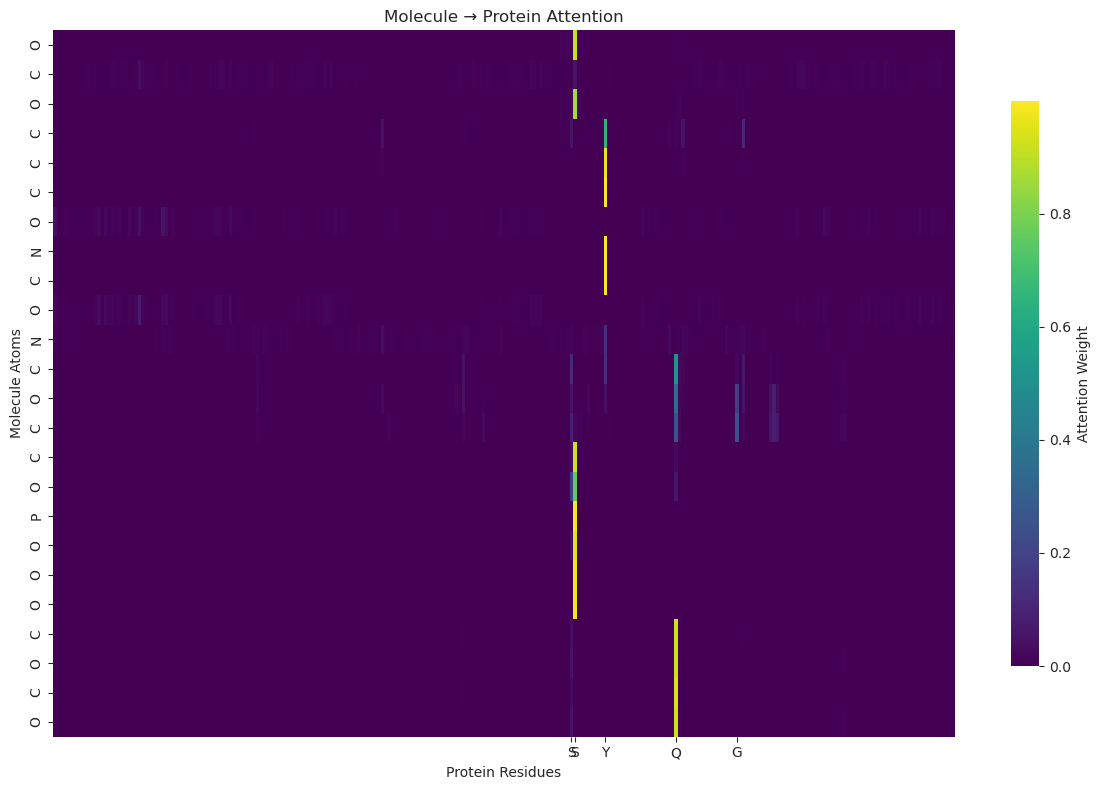

In [163]:
df_final = pd.read_csv('Mutant-info.csv')

def calculate_normalized_entropy(scores_1d):
    length = len(scores_1d)
    if length <= 1:
        return 0.0
    probs = scores_1d / (scores_1d.sum() + 1e-9)
    probs = probs[probs > 1e-9]
    raw_entropy = -np.sum(probs * np.log2(probs))
    return raw_entropy / np.log2(length)

i = 11026
seq = df_final['Sequence'][i]
smi = df_final['Smiles'][i]

# === Protein Embedding Info ===
prot_emb, prot_mask, prot_symbols = model.prot_emb([seq], return_symbols=True)
# prot_mask: (1, L_prot), prot_symbols: List[str] of length L_prot

# === Molecule Embedding Info ===
mol_out = model.mol_emb([smi], return_symbols=True)
# mol_out.atom_mask: (1, L_mol), mol_out.atom_symbols: List[str] of length L_mol

# === Attention Maps from Model Output ===
pred, attn_p2m, attn_m2p = model(
    protein_sequences=[seq],
    smiles_list=[smi],
    inter_model="both",
    return_attn=True
)

# Remove batch dimension (since batch_size=1)
prot_mask = prot_mask.squeeze(0)          # (L_prot,)
mol_mask = mol_out.atom_mask.squeeze(0)   # (L_mol,)
attn_p2m = attn_p2m.squeeze(0)            # (L_prot, L_mol)
attn_m2p = attn_m2p.squeeze(0)            # (L_mol, L_prot)

# Get real lengths (excluding padding)
real_prot_len = prot_mask.sum().item()
real_mol_len = mol_mask.sum().item()

# Extract valid attention submatrices
attn_p2m_real = attn_p2m[:real_prot_len, :real_mol_len].detach().cpu().numpy() # (P, M)
attn_m2p_real = attn_m2p[:real_mol_len, :real_prot_len].detach().cpu().numpy() # (M, P)

# Sequence Attention
aa_weights = attn_m2p_real.sum(axis=0)  # shape: (P,)

# Molecule Entropy
aa_entropies = np.array([calculate_normalized_entropy(attn_p2m_real[idx, :]) for idx in range(real_prot_len)]) # shape: (P,)
x_positions = np.arange(1, real_prot_len + 1)

# Get corresponding symbols
prot_seq = prot_symbols[0][:real_prot_len]        # List[str], e.g., ['M', 'K', 'T', ...]
mol_atoms = mol_out.atom_symbols[0][:real_mol_len]  # List[str], e.g., ['C', 'O', 'N', ...]

attn_real_detached = attn_m2p_real
avg_attn_per_residue = attn_real_detached.mean(axis=0)  # shape: (num_residues,)
k = min(5, len(avg_attn_per_residue))
top_k_indices = np.argsort(avg_attn_per_residue)[-k:]
top_k_indices = np.sort(top_k_indices)
top_k_labels = [prot_seq[i] for i in top_k_indices]

plt.figure(figsize=(12, 8))
sns.set_style("ticks")

ax = sns.heatmap(
    attn_real_detached,
    xticklabels=False,
    yticklabels=mol_atoms,
    cmap="viridis",
    cbar_kws={
        'label': 'Attention Weight',
        'shrink': 0.8,      
        'aspect': 20
    },
    linewidths=0,               
    rasterized=True
)

ax.set_xticks([i + 0.5 for i in top_k_indices])
ax.set_xticklabels(top_k_labels, rotation=0, fontsize=10)

plt.xlabel("Protein Residues")
plt.ylabel("Molecule Atoms")
plt.title("Molecule → Protein Attention")
plt.tight_layout()
# plt.savefig("molecule_to_protein_attention_real.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

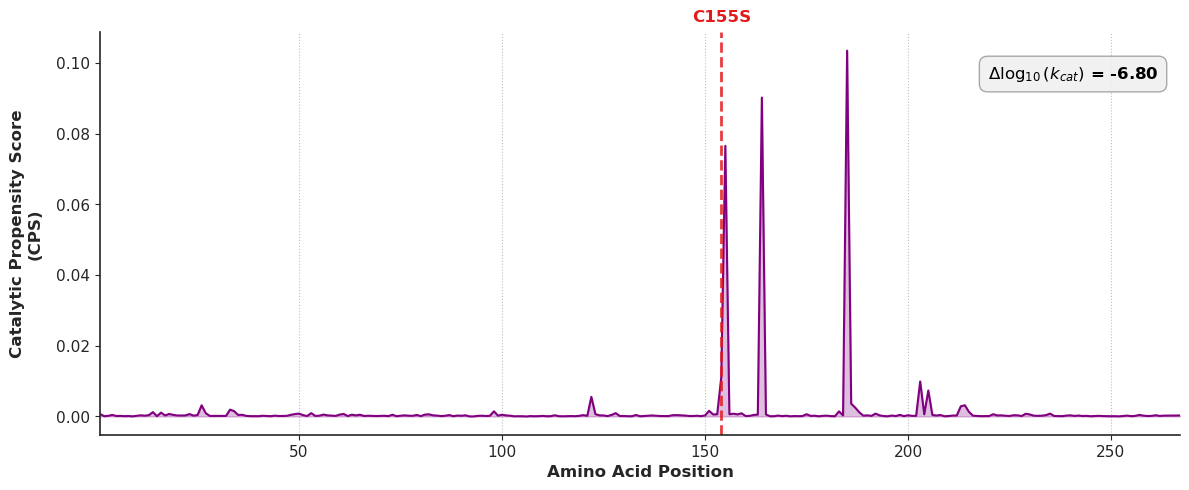

In [164]:
import re
import numpy as np
import matplotlib.pyplot as plt

# CPS calculation
w_min, w_max = aa_weights.min(), aa_weights.max()
aa_weights_norm = (aa_weights - w_min) / (w_max - w_min + 1e-9)
cps_scores = aa_weights_norm * (1.0 - aa_entropies)

delta_log_kcat = delta_df[delta_df['Original_Index'] == i]['Delta_log_kcat']
mutation_pos = [int(pos)-1 for pos in re.findall(r'\d+', df_final['Mutation_Info'][i])]
mutation_text = df_final['Mutation_Info'][i].split(';')

# --- Style Configuration ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.linewidth'] = 1.2

# Plotting
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(x_positions, cps_scores, color='purple', alpha=0.25)
ax.plot(x_positions, cps_scores, color='purple', linewidth=1.5)

ax.set_ylabel('Catalytic Propensity Score\n(CPS)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlabel('Amino Acid Position', fontsize=12, fontweight='bold')

props = dict(boxstyle='round,pad=0.5', facecolor='#F0F0F0', edgecolor='#A0A0A0', alpha=0.9)
delta_text = f"$\\Delta\\log_{{10}}(k_{{cat}})$ = {delta_log_kcat.values[0]:+.2f}"
ax.text(0.98, 0.92, delta_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', horizontalalignment='right', bbox=props, color='black', fontweight='bold')

for pos in mutation_pos:
    ax.axvline(x=pos, color='#E31A1C', linestyle='--', linewidth=2.0, alpha=0.85)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', direction='out', labelsize=11)

ax.xaxis.grid(True, linestyle=':', color='gray', alpha=0.5)

y_max = ax.get_ylim()[1]
for pos, text in zip(mutation_pos, mutation_text):
    ax.text(pos, y_max * 1.02, f"{text.strip()}", 
            color='#E31A1C', fontsize=12, fontweight='bold', ha='center', va='bottom')

ax.set_xlim(1, len(prot_seq))

plt.tight_layout()
plt.savefig(f"./Figure/CPS_Profile_{i}.png", dpi=600, bbox_inches='tight', transparent=True)
plt.show()

🚀 开始对 Top 2000 致死突变进行批量验证 (Radius = $\pm$5 AAs)...


Analyzing Mutations: 100%|██████████████████| 2000/2000 [01:04<00:00, 30.87it/s]


--------------------------------------------------
📊 统计结果汇总:
总突变位点数量: 4296
成功命中数量 (距离 <= 5): 889
✅ 模型实际命中率 (Hit Rate): 20.69%
🎲 理论随机命中率 (Random Guess): 16.15%
🌟 显著性检验 P-value: 3.13e-15
--------------------------------------------------


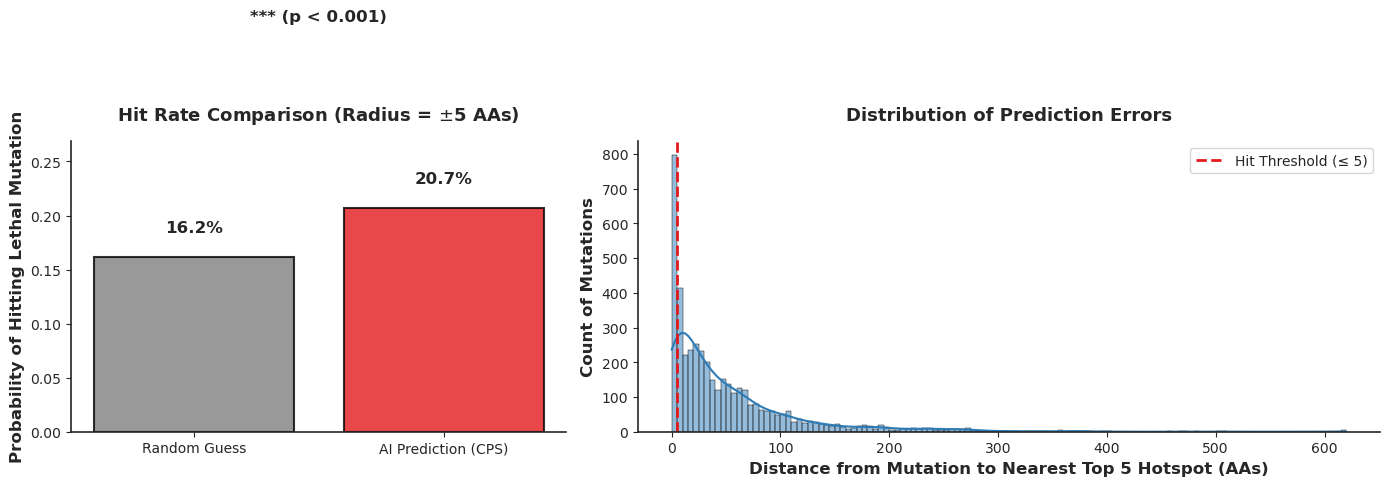


🔍 未命中记录检查 (可能存在变构效应或数据集标注偏差):


,Mutation,EC,Mut_Pos,Min_Dist
1,K443A ; K529A,1.13.12.7,529,78
3,D107A ; Q262A,1.1.1.282,262,27
11,Y44F,4.1.3.32,44,19
13,R222A ; R287A,3.2.1.28,222,28
15,E520A,3.2.1.28,520,170
...,...,...,...,...
4291,R193H,2.7.1.105,193,133
4292,R193H,2.7.1.105,193,133
4293,F137A,4.3.1.24,137,123
4294,T252Y,6.1.1.4,252,239


In [137]:
import re
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy.stats import binomtest  # 用于计算统计学 P-value

# ==========================================
# 1. 参数设置与数据筛选
# ==========================================
radius = 5  # 定义命中窗口半径为 ±5 个氨基酸
num_top_samples = 2000

# 筛选出导致 kcat 下降最严重（Delta < 0）的 Top 20 突变
top_lethal = delta_df.head(num_top_samples)

hit_count = 0
total_mut_points = 0
results_log = []

# ==========================================
# 2. 自动化批量验证流水线
# ==========================================
print(rf"🚀 开始对 Top {num_top_samples} 致死突变进行批量验证 (Radius = $\pm${radius} AAs)...")

# 遍历这 20 个极端突变事件
for _, row in tqdm(top_lethal.iterrows(), total=len(top_lethal), desc="Analyzing Mutations"):
    idx = row['Original_Index']
    mut_info = row['Mutation_Info']
    
    # 提取突变位点 (支持单点和多点突变，如 "C155S" 或 "K443A ; K529A")
    mut_positions = [int(p) for p in re.findall(r'\d+', mut_info)]
    if not mut_positions:
        continue
        
    seq = df_final['Sequence'].iloc[idx]
    smi = df_final['Smiles'].iloc[idx]
    
    # --- A. 模型推理 ---
    with torch.no_grad(): # 节省显存
        prot_emb, prot_mask, prot_symbols = model.prot_emb([seq], return_symbols=True)
        mol_out = model.mol_emb([smi], return_symbols=True)
        pred, attn_p2m, attn_m2p = model(
            protein_sequences=[seq], smiles_list=[smi],
            inter_model="both", return_attn=True
        )
        
    # --- B. 数据清洗 (去除特殊符号) ---
    real_prot_len = prot_mask.sum().item()
    real_mol_len = mol_out.atom_mask.sum().item()
    start_idx = 1 if len(prot_symbols[0][0]) > 1 else 0
    end_offset = 1 if len(prot_symbols[0][real_prot_len-1]) > 1 else 0
    pure_prot_len = real_prot_len - start_idx - end_offset
    
    attn_p2m_pure = attn_p2m[0, start_idx : real_prot_len - end_offset, :real_mol_len].cpu().numpy()
    attn_m2p_pure = attn_m2p[0, :real_mol_len, start_idx : real_prot_len - end_offset].cpu().numpy()
    
    # --- C. 计算特征得分 (CPS) ---
    aa_weights = attn_m2p_pure.sum(axis=0)
    w_min, w_max = aa_weights.min(), aa_weights.max()
    aa_weights_norm = (aa_weights - w_min) / (w_max - w_min + 1e-9)
    
    def calc_entropy(dist):
        probs = dist[dist > 1e-9]
        if len(dist) <= 1: return 0.0
        return -np.sum(probs * np.log2(probs)) / np.log2(len(dist))
        
    aa_entropies = np.array([calc_entropy(attn_p2m_pure[i, :]) for i in range(pure_prot_len)])
    cps_scores = aa_weights_norm * (1.0 - aa_entropies)
    
    # 提取 CPS Top 5 核心热点位置 (1-based)
    top_5_pos = np.argsort(cps_scores)[-5:] + 1
    
    # --- D. 距离测算与命中统计 ---
    for mp in mut_positions:
        if mp > pure_prot_len: continue # 容错保护
            
        total_mut_points += 1
        
        # 计算当前突变距离 Top 5 的最短距离
        dist = np.min(np.abs(top_5_pos - mp))
        is_hit = dist <= radius
        
        if is_hit:
            hit_count += 1
            
        results_log.append({
            'Mutation': mut_info,
            'EC': row['ECNumber'],
            'Seq_Len': pure_prot_len,
            'Mut_Pos': mp,
            'Min_Dist': dist,
            'Is_Hit': is_hit,
            'Delta_log_kcat': row['Delta_log_kcat']
        })

# ==========================================
# 3. 统计学分析与 P-value 计算
# ==========================================
df_results = pd.DataFrame(results_log)
hit_rate = hit_count / total_mut_points

# 零假设（随机概率）：瞎猜 5 个热点，在 ±5 半径内撞上突变的概率
# 面积估算：5个热点 * 每个占据 (2*R + 1) 个位置 / 序列总长度
expected_random_probs = [min(1.0, 5 * (2 * radius + 1) / r['Seq_Len']) for r in results_log]
avg_random_prob = np.mean(expected_random_probs)

# 二项式检验：实际命中次数 是否显著高于 随机命中次数
p_value = binomtest(hit_count, total_mut_points, avg_random_prob, alternative='greater').pvalue

print("-" * 50)
print(f"📊 统计结果汇总:")
print(f"总突变位点数量: {total_mut_points}")
print(f"成功命中数量 (距离 <= {radius}): {hit_count}")
print(f"✅ 模型实际命中率 (Hit Rate): {hit_rate:.2%}")
print(f"🎲 理论随机命中率 (Random Guess): {avg_random_prob:.2%}")
print(f"🌟 显著性检验 P-value: {p_value:.2e}")
print("-" * 50)

# ==========================================
# 4. 可视化报告生成 (论文必备插图)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1, 1.5]})

# --- 子图 1: 命中率对比 (柱状图) ---
bars = ax1.bar(['Random Guess', 'AI Prediction (CPS)'], [avg_random_prob, hit_rate], 
               color=['gray', '#E31A1C'], alpha=0.8, edgecolor='black', linewidth=1.5)
ax1.set_ylim(0, max(hit_rate, avg_random_prob) * 1.3)
ax1.set_ylabel('Probability of Hitting Lethal Mutation', fontsize=12, fontweight='bold')
ax1.set_title(rf'Hit Rate Comparison (Radius = $\pm${radius} AAs)', fontsize=13, fontweight='bold', pad=15)

# 添加数值标签
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# 添加 P-value 星号标注
y_max = max(hit_rate, avg_random_prob)
ax1.plot([0, 0, 1, 1], [y_max+0.1, y_max+0.15, y_max+0.15, y_max+0.1], lw=1.5, c='k')
p_text = '*** (p < 0.001)' if p_value < 0.001 else f'p = {p_value:.3f}'
ax1.text(0.5, y_max+0.17, p_text, ha='center', va='bottom', fontsize=12, fontweight='bold')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- 子图 2: 具体距离分布 (直方图) ---
distances = df_results['Min_Dist'].values
sns.histplot(distances, bins=range(0, int(max(distances))+5, 5), kde=True, ax=ax2, color='#2C7BB6', edgecolor='black')
ax2.axvline(x=radius, color='#E31A1C', linestyle='--', linewidth=2, label=f'Hit Threshold (≤ {radius})')

ax2.set_xlabel('Distance from Mutation to Nearest Top 5 Hotspot (AAs)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count of Mutations', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Prediction Errors', fontsize=13, fontweight='bold', pad=15)
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
# plt.savefig("Statistical_Validation_Hit_Rate.png", dpi=600, bbox_inches='tight')
plt.show()

# 打印出未命中的反例以便后续分析
print("\n🔍 未命中记录检查 (可能存在变构效应或数据集标注偏差):")
display(df_results[df_results['Is_Hit'] == False][['Mutation', 'EC', 'Mut_Pos', 'Min_Dist']])

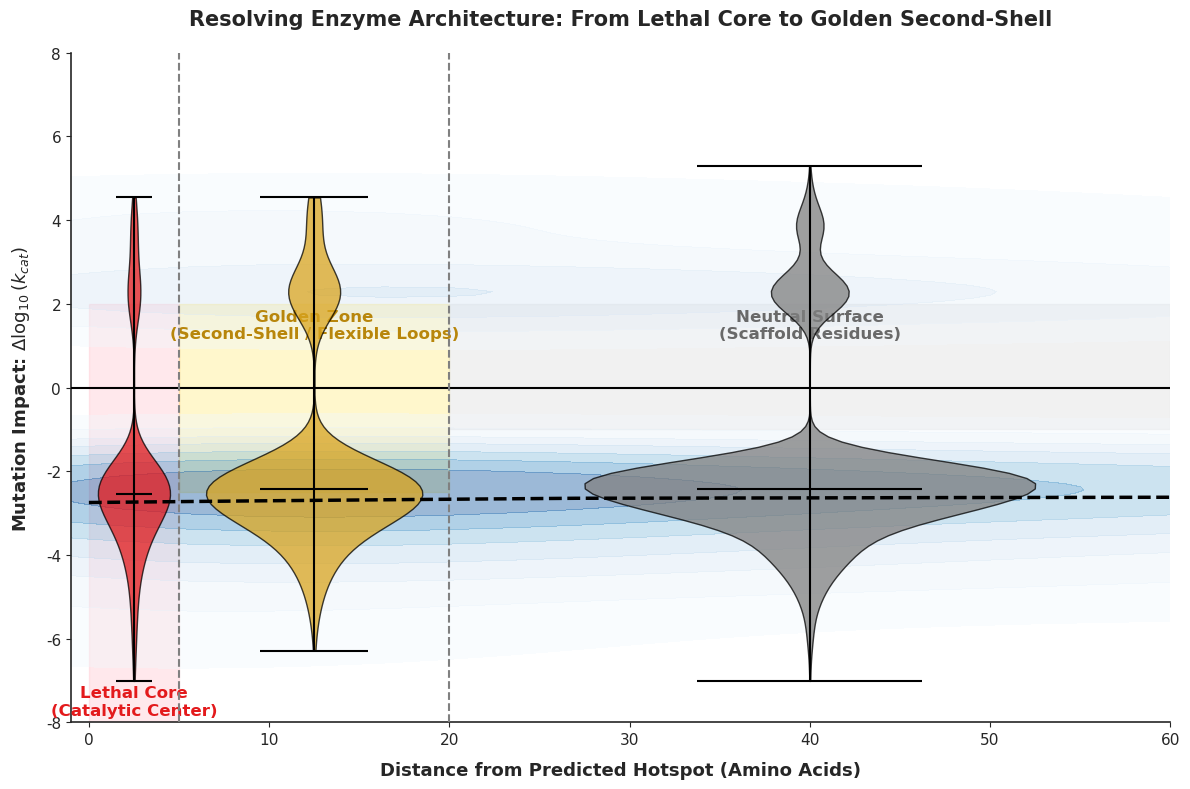

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

# ==========================================
# 1. 假设的数据集准备
# ==========================================
# df_results = pd.read_csv('your_pipeline_results.csv') 

# 模拟数据供测试代码使用(如果你已经有 df_results 请注释掉以下两行)
# distances = np.random.exponential(15, 1000)
# delta_kcat = -np.random.lognormal(mean=1, sigma=0.8, size=1000) * np.exp(-distances/10)

# ==========================================
# 2. Nature-Style 绘图设置与底图初始化
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

fig, ax = plt.subplots(figsize=(12, 8))

# ==========================================
# 3. 绘制三大核心区域 (背景色块)
# ==========================================
y_min, y_max = -8, 2  # 根据你的数据调整 y 轴范围
x_max = 60            # 设定最大观察距离

# 区域 A: 致死核心区 (Core Zone) - 红色警戒
ax.add_patch(Rectangle((0, -8), 5, 10, color='#FFB6C1', alpha=0.3, zorder=1))
ax.text(2.5, -7.5, "Lethal Core\n(Catalytic Center)", color='#E31A1C', 
        fontweight='bold', fontsize=12, ha='center', va='center')

# 区域 B: 黄金次级壳层 (Golden Second-Shell) - 金色寻宝区
ax.add_patch(Rectangle((5, -2.5), 15, 4.5, color='#FFD700', alpha=0.2, zorder=1))
ax.text(12.5, 1.5, "Golden Zone\n(Second-Shell / Flexible Loops)", color='#B8860B', 
        fontweight='bold', fontsize=12, ha='center', va='center')

# 区域 C: 中性表面区 (Neutral Surface) - 灰色无效区
ax.add_patch(Rectangle((20, -1), 40, 3, color='#D3D3D3', alpha=0.3, zorder=1))
ax.text(40, 1.5, "Neutral Surface\n(Scaffold Residues)", color='#696969', 
        fontweight='bold', fontsize=12, ha='center', va='center')

# ==========================================
# 4. 绘制核密度云图与小提琴图 (替换散点图)
# ==========================================
distances = df_results['Min_Dist'].values
delta_kcat = df_results['Delta_log_kcat'].values

# (1) 绘制底层密度等高线 (依然保留，用于展示整体宏观梯度)
sns.kdeplot(x=distances, y=delta_kcat, cmap="Blues", fill=True, alpha=0.4, thresh=0.05, levels=8, ax=ax, zorder=2)

# (2) 数据切片：按三大区域分组提取 Delta_kcat
data_core = delta_kcat[(distances >= 0) & (distances <= 5)]
data_gold = delta_kcat[(distances > 5) & (distances <= 20)]
data_neut = delta_kcat[distances > 20]

# (3) 设置小提琴图的参数 (放置在各个色块的正中间，宽度自适应色块宽度)
vp_positions = [2.5, 12.5, 40]   # 分别对应 0-5, 5-20, 20-60 的中心位置
vp_widths = [4, 12, 25]          # 宽度不超过背景色块
vp_colors = ['#E31A1C', '#DAA520', '#808080']  # 核心红, 黄金色, 中性灰

# 确保每个区间至少有数据才绘制，避免报错
plot_data = [d for d in [data_core, data_gold, data_neut] if len(d) > 0]
plot_pos = [vp_positions[i] for i, d in enumerate([data_core, data_gold, data_neut]) if len(d) > 0]
plot_wid = [vp_widths[i] for i, d in enumerate([data_core, data_gold, data_neut]) if len(d) > 0]
plot_col = [vp_colors[i] for i, d in enumerate([data_core, data_gold, data_neut]) if len(d) > 0]

# 绘制小提琴图
if plot_data:
    parts = ax.violinplot(plot_data, positions=plot_pos, widths=plot_wid, 
                          showmeans=False, showmedians=True, showextrema=True)
    
    # 调整小提琴图的颜色和样式
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(plot_col[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.75) # 透明度调高，突出显示
        pc.set_zorder(4)
    
    # 修改小提琴内部线条的颜色
    for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians'):
        vp = parts[partname]
        vp.set_edgecolor('black')
        vp.set_linewidth(1.5)
        vp.set_zorder(5)

# (4) 绘制平滑趋势线 (LOESS / 移动平均)
sns.regplot(x=distances, y=delta_kcat, scatter=False, color='black', 
            lowess=True, line_kws={'linestyle':'--', 'linewidth': 2.5, 'zorder': 6}, ax=ax)

# ==========================================
# 5. 辅助线与图表美化
# ==========================================
ax.axhline(0, color='black', linewidth=1.5, linestyle='-', zorder=3)      # 基准线 (WT 活性)
ax.axvline(5, color='gray', linewidth=1.5, linestyle='--', zorder=3)      # 核心区边界
ax.axvline(20, color='gray', linewidth=1.5, linestyle='--', zorder=3)     # 次级壳层边界

ax.set_xlim(-1, x_max)
ax.set_ylim(y_min, y_max+6)

ax.set_xlabel('Distance from Predicted Hotspot (Amino Acids)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel(r'Mutation Impact: $\Delta\log_{10}(k_{cat})$', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('Resolving Enzyme Architecture: From Lethal Core to Golden Second-Shell', 
             fontsize=15, fontweight='bold', pad=20)

# 美化边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
# plt.savefig('Enzyme_Navigation_Map_Violin.png', dpi=600, bbox_inches='tight')
plt.show()

### Model Application: Predicting kcat for a new enzyme-substrate pair

### Other Operation

In [ ]:
from transformers import AutoTokenizer, AutoModel
import math
import torch
import torch.nn as nn
import pandas as pd
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com' # Set Hugging Face endpoint to a mirror
os.chdir('/home/weiren')
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ESM_MODEL_NAME = "facebook/esm2_t30_150M_UR50D"
# ESM_MODEL_NAME = "facebook/esm2_t12_35M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(ESM_MODEL_NAME)
esm_model = AutoModel.from_pretrained(ESM_MODEL_NAME).to(DEVICE)

In [ ]:
df = pd.read_csv('EITLEM_KCAT.csv')
df

In [ ]:
input_ids = tokenizer(df['Sequence'][1], return_tensors="pt")['input_ids'].to(DEVICE)
attention_mask = tokenizer(df['Sequence'][1], return_tensors="pt")['attention_mask'].to(DEVICE)
esm_model.eval()
embeddings = esm_model(input_ids, attention_mask=attention_mask, return_dict=True)['last_hidden_state']

In [ ]:
embeddings.shape # torch.Size([1, seq_len, dim])

In [ ]:
tokenizer.decode(input_ids[0])